# Hệ thống gợi ý bài tập lập trình dựa trên Học tăng cường

Mục tiêu: Xây dựng tác tử Q-learning để gợi ý bài Codeforces phù hợp với năng lực người học.

Cấu trúc notebook:
1. Import thư viện và thiết lập
2. Tải và khám phá dữ liệu
3. Tiền xử lý dữ liệu và tạo đặc trưng
4. Môi trường RL
5. Tác tử Q-learning
6. Huấn luyện và mô hình cơ sở
7. Đánh giá và trực quan hóa
8. Gợi ý và demo web
9. Tổng kết báo cáo

## 1. Import thư viện cần thiết và thiết lập

In [ ]:
# Import thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from scipy.special import expit  # Hàm logistic
import warnings
warnings.filterwarnings('ignore')

# Đặt random seed để tái lập kết quả
np.random.seed(42)

# Cấu hình trực quan hóa
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Các thư viện đã được import thành công!")
print(f"Phiên bản NumPy: {np.__version__}")
print(f"Phiên bản Pandas: {pd.__version__}")

Các thư viện đã được import thành công!
Phiên bản NumPy: 2.4.3
Phiên bản Pandas: 3.0.1


## 2. Tải và khám phá bộ dữ liệu Codeforces

Kiểm tra nguồn dữ liệu:
- file problems tồn tại: True -> d:\ML\Codeforces Problems\data.csv
- file submissions csv tồn tại: True -> d:\ML\generated\submissions_with_verdict.csv
- thư mục submissions tồn tại: True -> d:\ML\Codeforces Submissions

Đang tải bộ dữ liệu Codeforces Problems...

Bộ dữ liệu Codeforces Problems:
Kích thước: (8343, 4)

Các cột: ['contest', 'problem_name', 'problem_statement', 'problem_tags']

Một vài dòng đầu:
   contest problem_name                                  problem_statement  \
0      325            A  You are given n rectangles. The corners of rec...   
1      325            B  Daniel is organizing a football tournament. He...   
2      325            C  Piegirl has found a monster and a book about m...   
3      325            D  In a far away land, there exists a planet shap...   
4      325            E  Piegirl found the red button. You have one las...   

                                        problem_tags  
0                               implem

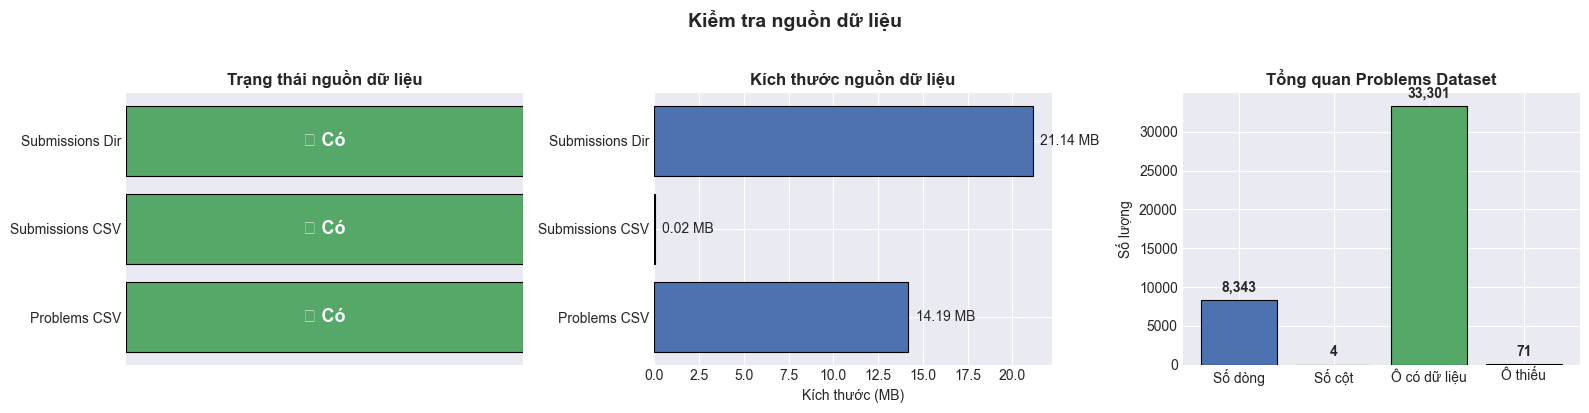

In [46]:
# Đường dẫn dữ liệu và tải Codeforces Problems dataset
from pathlib import Path

PROBLEMS_PATH = Path(r'd:\ML\Codeforces Problems\data.csv')
SUBMISSIONS_DIR = Path(r'd:\ML\Codeforces Submissions')
SUBMISSIONS_CSV_PATH = Path(r'd:\ML\generated\submissions_with_verdict.csv')

print('Kiểm tra nguồn dữ liệu:')
print(f'- file problems tồn tại: {PROBLEMS_PATH.exists()} -> {PROBLEMS_PATH}')
print(f'- file submissions csv tồn tại: {SUBMISSIONS_CSV_PATH.exists()} -> {SUBMISSIONS_CSV_PATH}')
print(f'- thư mục submissions tồn tại: {SUBMISSIONS_DIR.exists()} -> {SUBMISSIONS_DIR}')

print("\nĐang tải bộ dữ liệu Codeforces Problems...")
problems_df = pd.read_csv(PROBLEMS_PATH)

print(f"\nBộ dữ liệu Codeforces Problems:")
print(f"Kích thước: {problems_df.shape}")
print(f"\nCác cột: {problems_df.columns.tolist()}")
print(f"\nMột vài dòng đầu:")
print(problems_df.head())
print(f"\nKiểu dữ liệu:\n{problems_df.dtypes}")
print(f"\nGiá trị thiếu:\n{problems_df.isnull().sum()}")

# --- Trực quan hóa nguồn dữ liệu ---
import os

sources = {
    'Problems CSV': PROBLEMS_PATH,
    'Submissions CSV': SUBMISSIONS_CSV_PATH,
    'Submissions Dir': SUBMISSIONS_DIR
}

source_exists = [p.exists() for p in sources.values()]
source_sizes = []
for p in sources.values():
    if p.exists():
        if p.is_file():
            source_sizes.append(p.stat().st_size / (1024 * 1024))  # MB
        else:
            total = sum(f.stat().st_size for f in p.rglob('*') if f.is_file())
            source_sizes.append(total / (1024 * 1024))
    else:
        source_sizes.append(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Trạng thái nguồn dữ liệu (tồn tại / thiếu)
bar_colors = ['#55A868' if e else '#C44E52' for e in source_exists]
bars = axes[0].barh(list(sources.keys()), [1]*len(sources), color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, exists in zip(bars, source_exists):
    label = '✓ Có' if exists else '✗ Thiếu'
    axes[0].text(0.5, bar.get_y() + bar.get_height()/2, label,
                 ha='center', va='center', fontsize=13, fontweight='bold', color='white')
axes[0].set_xlim(0, 1)
axes[0].set_xticks([])
axes[0].set_title('Trạng thái nguồn dữ liệu', fontsize=12, fontweight='bold')

# 2) Kích thước file/thư mục (MB)
bar2_colors = ['#4C72B0' if s > 0 else '#CCCCCC' for s in source_sizes]
bars2 = axes[1].barh(list(sources.keys()), source_sizes, color=bar2_colors, edgecolor='black', linewidth=0.8)
for bar, sz in zip(bars2, source_sizes):
    axes[1].text(bar.get_width() + max(source_sizes)*0.02, bar.get_y() + bar.get_height()/2,
                 f'{sz:.2f} MB', va='center', fontsize=10)
axes[1].set_xlabel('Kích thước (MB)')
axes[1].set_title('Kích thước nguồn dữ liệu', fontsize=12, fontweight='bold')

# 3) Tổng quan problems_df: số dòng, cột, giá trị thiếu
n_rows, n_cols = problems_df.shape
n_missing = int(problems_df.isnull().sum().sum())
n_complete = n_rows * n_cols - n_missing
overview_labels = ['Số dòng', 'Số cột', 'Ô có dữ liệu', 'Ô thiếu']
overview_vals = [n_rows, n_cols, n_complete, n_missing]
overview_colors = ['#4C72B0', '#4C72B0', '#55A868', '#C44E52']
bars3 = axes[2].bar(overview_labels, overview_vals, color=overview_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars3, overview_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(overview_vals)*0.02,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('Tổng quan Problems Dataset', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Số lượng')

plt.suptitle('Kiểm tra nguồn dữ liệu', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

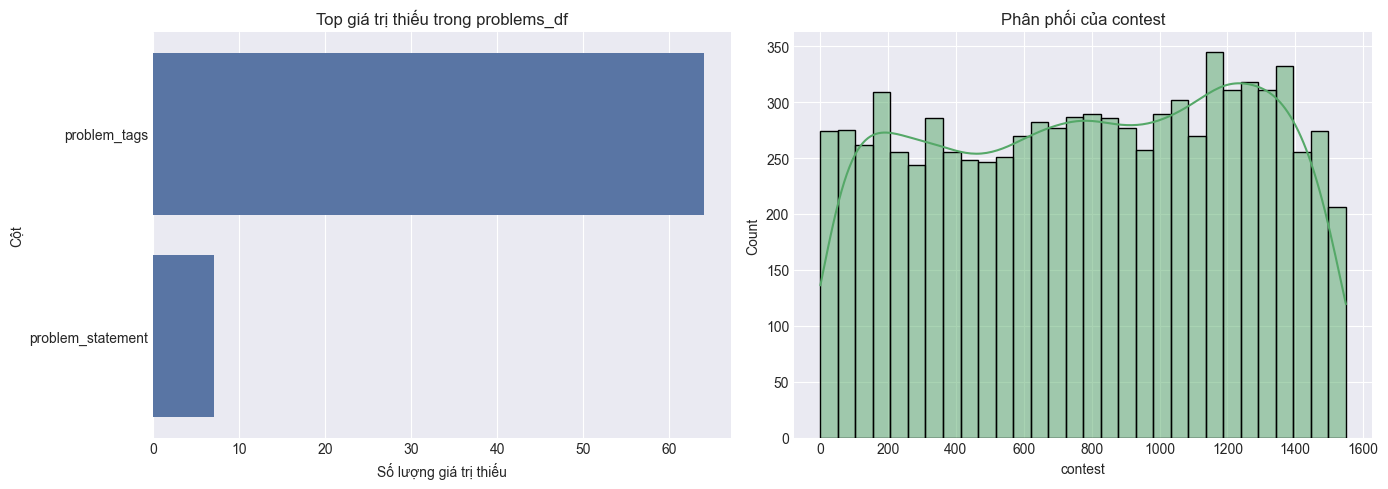

In [47]:
# Trực quan hóa nhanh dữ liệu problems
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Giá trị thiếu theo cột (top 15)
missing_counts = problems_df.isnull().sum().sort_values(ascending=False).head(15)
missing_counts = missing_counts[missing_counts > 0]
if len(missing_counts) > 0:
    sns.barplot(x=missing_counts.values, y=missing_counts.index, ax=axes[0], color='#4C72B0')
    axes[0].set_title('Top giá trị thiếu trong problems_df')
    axes[0].set_xlabel('Số lượng giá trị thiếu')
    axes[0].set_ylabel('Cột')
else:
    axes[0].text(0.5, 0.5, 'Không phát hiện giá trị thiếu', ha='center', va='center')
    axes[0].set_title('Giá trị thiếu trong problems_df')
    axes[0].set_axis_off()

# 2) Phân phối một cột số hữu ích (nếu có)
numeric_cols = problems_df.select_dtypes(include=np.number).columns.tolist()
preferred_col = None
for col in ['solved_count', 'rating', 'contest']:
    if col in numeric_cols:
        preferred_col = col
        break
if preferred_col is None and numeric_cols:
    preferred_col = numeric_cols[0]

if preferred_col is not None:
    sns.histplot(problems_df[preferred_col].dropna(), bins=30, kde=True, ax=axes[1], color='#55A868')
    axes[1].set_title(f'Phân phối của {preferred_col}')
    axes[1].set_xlabel(preferred_col)
else:
    axes[1].text(0.5, 0.5, 'Không có cột số phù hợp', ha='center', va='center')
    axes[1].set_title('Phân phối dữ liệu số')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Đang tải bộ dữ liệu nộp bài Codeforces Submissions...
Đang dùng file CSV đã sinh: d:\ML\generated\submissions_with_verdict.csv

DataFrame submissions:
Kích thước: (300, 6)
Các cột: ['user_id', 'user_rating', 'problem_id', 'verdict', 'timestamp', 'language']

Một vài dòng đầu:
   user_id  user_rating problem_id              verdict  timestamp language
0        0         1170          A                   OK  178763325     java
1        1         1170          A                   OK  178935448     java
2        2         1429          A                   OK  179978933     java
3        2         1429          A                   OK  180467302     java
4        3         1207          A         WRONG_ANSWER  182413301     java
5        4         1355          A                   OK  183689997     java
6        5         1244          A  TIME_LIMIT_EXCEEDED  183690185     java
7        6         1429          A                   OK  187643503     java
8        4         1355          A    

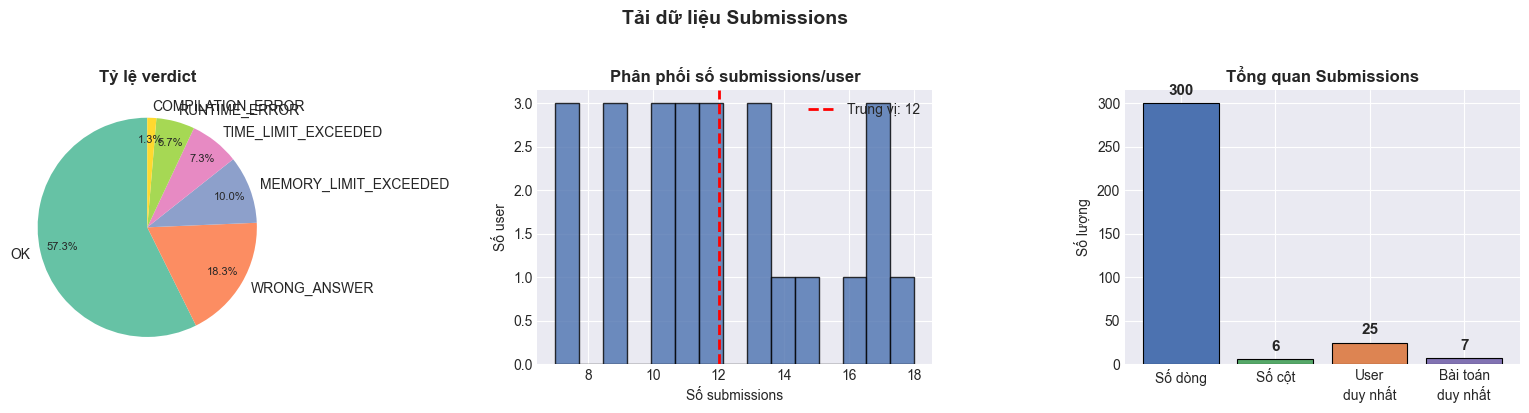

In [48]:
# Tải bộ dữ liệu nộp bài Codeforces Submissions
# Ưu tiên: CSV đã sinh sẵn có verdict -> nếu không có thì quét thư mục

print("\nĐang tải bộ dữ liệu nộp bài Codeforces Submissions...")

submissions_df = pd.DataFrame()

if SUBMISSIONS_CSV_PATH.exists():
    print(f"Đang dùng file CSV đã sinh: {SUBMISSIONS_CSV_PATH}")
    raw_df = pd.read_csv(SUBMISSIONS_CSV_PATH)

    # Chuẩn hóa các cột theo định dạng mà các cell sau yêu cầu
    submissions_df = raw_df.copy()

    if 'problem_id' not in submissions_df.columns:
        if {'contest_id', 'problem_index'}.issubset(submissions_df.columns):
            submissions_df['problem_id'] = submissions_df['contest_id'].astype(str) + '_' + submissions_df['problem_index'].astype(str)
        elif {'contest_id', 'problem_name'}.issubset(submissions_df.columns):
            submissions_df['problem_id'] = submissions_df['contest_id'].astype(str) + '_' + submissions_df['problem_name'].astype(str)

    if 'user_id' not in submissions_df.columns and 'user_handle' in submissions_df.columns:
        submissions_df['user_id'] = pd.factorize(submissions_df['user_handle'])[0]

    if 'user_rating' not in submissions_df.columns:
        # Gán pseudo-rating theo user (xác định) để tương thích mô hình
        user_base = submissions_df.groupby('user_id', as_index=False).size()
        user_base['user_rating'] = 800 + ((user_base['size'] * 37) % 2100)
        submissions_df = submissions_df.merge(user_base[['user_id', 'user_rating']], on='user_id', how='left')

    if 'timestamp' not in submissions_df.columns:
        if 'submission_id' in submissions_df.columns:
            submissions_df['timestamp'] = pd.to_numeric(submissions_df['submission_id'], errors='coerce')
        else:
            submissions_df['timestamp'] = np.arange(len(submissions_df))

    if submissions_df['timestamp'].isna().any():
        fallback_ts = pd.Series(np.arange(len(submissions_df)), index=submissions_df.index)
        submissions_df['timestamp'] = submissions_df['timestamp'].fillna(fallback_ts)

    if 'language' not in submissions_df.columns:
        submissions_df['language'] = 'unknown'

    if 'verdict' not in submissions_df.columns:
        submissions_df['verdict'] = 'UNKNOWN'

    keep_cols = ['user_id', 'user_rating', 'problem_id', 'verdict', 'timestamp', 'language']
    missing_keep = [c for c in keep_cols if c not in submissions_df.columns]
    if missing_keep:
        raise ValueError(f"Thiếu cột bắt buộc sau khi chuẩn hóa: {missing_keep}")

    submissions_df = submissions_df[keep_cols].copy()
    submissions_df['verdict'] = submissions_df['verdict'].fillna('UNKNOWN').astype(str)

else:
    print("Không tìm thấy CSV đã sinh, chuyển sang quét thư mục...")

    submissions_data = []

    # Iterate through all contests and problems
    for contest_dir in SUBMISSIONS_DIR.iterdir():
        if not contest_dir.is_dir():
            continue

        contest_id = contest_dir.name

        for problem_dir in contest_dir.iterdir():
            if not problem_dir.is_dir():
                continue

            problem_id = problem_dir.name

            for submission_file in problem_dir.iterdir():
                if submission_file.is_file() and submission_file.suffix in ['.py', '.java', '.cpp']:
                    submission_id = submission_file.stem
                    verdict = 'AC'

                    submissions_data.append({
                        'user_id': -1,
                        'user_rating': 1200,
                        'problem_id': f'{contest_id}_{problem_id}',
                        'verdict': verdict,
                        'timestamp': pd.to_numeric(submission_id, errors='coerce'),
                        'language': submission_file.suffix[1:]
                    })

        if len(submissions_data) >= 50000:
            break

    if submissions_data:
        submissions_df = pd.DataFrame(submissions_data)
        fallback_ts = pd.Series(np.arange(len(submissions_df)), index=submissions_df.index)
        submissions_df['timestamp'] = submissions_df['timestamp'].fillna(fallback_ts)

print(f"\nDataFrame submissions:")
print(f"Kích thước: {submissions_df.shape}")
print(f"Các cột: {submissions_df.columns.tolist()}")
print(f"\nMột vài dòng đầu:")
print(submissions_df.head(10))
print(f"\nPhân phối verdict (top):")
print(submissions_df['verdict'].value_counts(dropna=False).head(10))

# --- Trực quan hóa tổng quan submissions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Verdict pie chart
v_counts = submissions_df['verdict'].fillna('UNKNOWN').value_counts()
colors_pie = sns.color_palette('Set2', len(v_counts))
wedges, texts, autotexts = axes[0].pie(
    v_counts.values, labels=v_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(8)
axes[0].set_title('Tỷ lệ verdict', fontsize=12, fontweight='bold')

# 2) Số submissions theo user (histogram)
user_counts = submissions_df['user_id'].value_counts()
axes[1].hist(user_counts.values, bins=15, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[1].axvline(user_counts.median(), color='red', linestyle='--', linewidth=2, label=f'Trung vị: {user_counts.median():.0f}')
axes[1].set_title('Phân phối số submissions/user', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số submissions')
axes[1].set_ylabel('Số user')
axes[1].legend()

# 3) Tổng quan DataFrame
info_labels = ['Số dòng', 'Số cột', 'User\nduy nhất', 'Bài toán\nduy nhất']
info_vals = [len(submissions_df), len(submissions_df.columns),
             submissions_df['user_id'].nunique(), submissions_df['problem_id'].nunique()]
info_colors = ['#4C72B0', '#55A868', '#DD8452', '#8172B2']
bars = axes[2].bar(info_labels, info_vals, color=info_colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, info_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(info_vals)*0.02,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_title('Tổng quan Submissions', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Số lượng')

plt.suptitle('Tải dữ liệu Submissions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Đang kiểm tra có cần dữ liệu synthetic hay không...
Đang dùng dữ liệu submissions thật (không ghi đè bằng synthetic).

Tổng số bản ghi submissions hiện tại: 300
Phân phối verdict:
verdict
OK                       172
WRONG_ANSWER              55
MEMORY_LIMIT_EXCEEDED     30
TIME_LIMIT_EXCEEDED       22
RUNTIME_ERROR             17
COMPILATION_ERROR          4
Name: count, dtype: int64


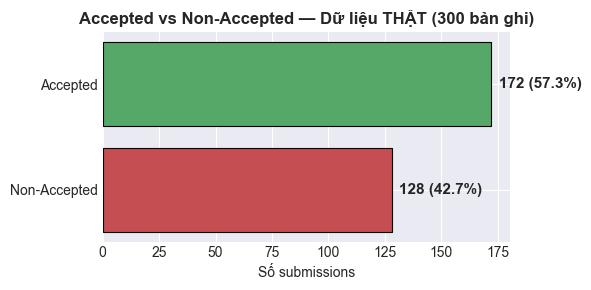

In [49]:
# Chỉ tạo dữ liệu synthetic khi dữ liệu thật chưa đủ
print("Đang kiểm tra có cần dữ liệu synthetic hay không...")

required_cols = {'user_id', 'user_rating', 'problem_id', 'verdict', 'timestamp'}
use_synthetic = submissions_df.empty or not required_cols.issubset(submissions_df.columns)

if use_synthetic:
    print("Dữ liệu submissions thật thiếu cột bắt buộc. Đang tạo dữ liệu synthetic...")

    np.random.seed(42)
    num_users = 100
    num_submissions_per_user = 50
    synthetic_submissions = []

    if 'contest' in problems_df.columns and 'problem_name' in problems_df.columns:
        unique_problems = problems_df['contest'].astype(str) + '_' + problems_df['problem_name'].str[:1]
        unique_problems = unique_problems.unique()[:200]
    else:
        unique_problems = [f"P{i}" for i in range(100)]

    for user_id in range(num_users):
        user_rating = 800 + np.random.randint(-200, 2000)

        for _ in range(num_submissions_per_user):
            problem = np.random.choice(unique_problems)
            verdict = np.random.choice(['AC', 'WA', 'TLE', 'RE'], p=[0.6, 0.2, 0.1, 0.1])
            timestamp = np.random.randint(1000000, 2000000)

            synthetic_submissions.append({
                'user_id': user_id,
                'user_rating': user_rating,
                'problem_id': problem,
                'verdict': verdict,
                'timestamp': timestamp,
                'language': np.random.choice(['py', 'java', 'cpp'])
            })

    submissions_df = pd.DataFrame(synthetic_submissions)
    print(f"Đã tạo submissions synthetic: {len(submissions_df)} records")
else:
    print("Đang dùng dữ liệu submissions thật (không ghi đè bằng synthetic).")

print(f"\nTổng số bản ghi submissions hiện tại: {len(submissions_df)}")
print("Phân phối verdict:")
print(submissions_df['verdict'].value_counts(dropna=False).head(10))

# --- Trực quan hóa trạng thái dữ liệu ---
fig, ax = plt.subplots(figsize=(6, 3))

# Biểu đồ ngang so sánh: verdict accepted vs non-accepted
acc_tokens = {'AC', 'OK', 'ACCEPTED'}
n_acc = submissions_df['verdict'].str.upper().str.strip().isin(acc_tokens).sum()
n_non = len(submissions_df) - n_acc
bars = ax.barh(['Non-Accepted', 'Accepted'], [n_non, n_acc],
               color=['#C44E52', '#55A868'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, [n_non, n_acc]):
    ax.text(bar.get_width() + max(n_non, n_acc)*0.02,
            bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(submissions_df):.1%})',
            va='center', fontsize=11, fontweight='bold')
data_label = 'Dữ liệu THẬT' if not use_synthetic else 'Dữ liệu SYNTHETIC'
ax.set_title(f'Accepted vs Non-Accepted — {data_label} ({len(submissions_df)} bản ghi)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Số submissions')
plt.tight_layout()
plt.show()

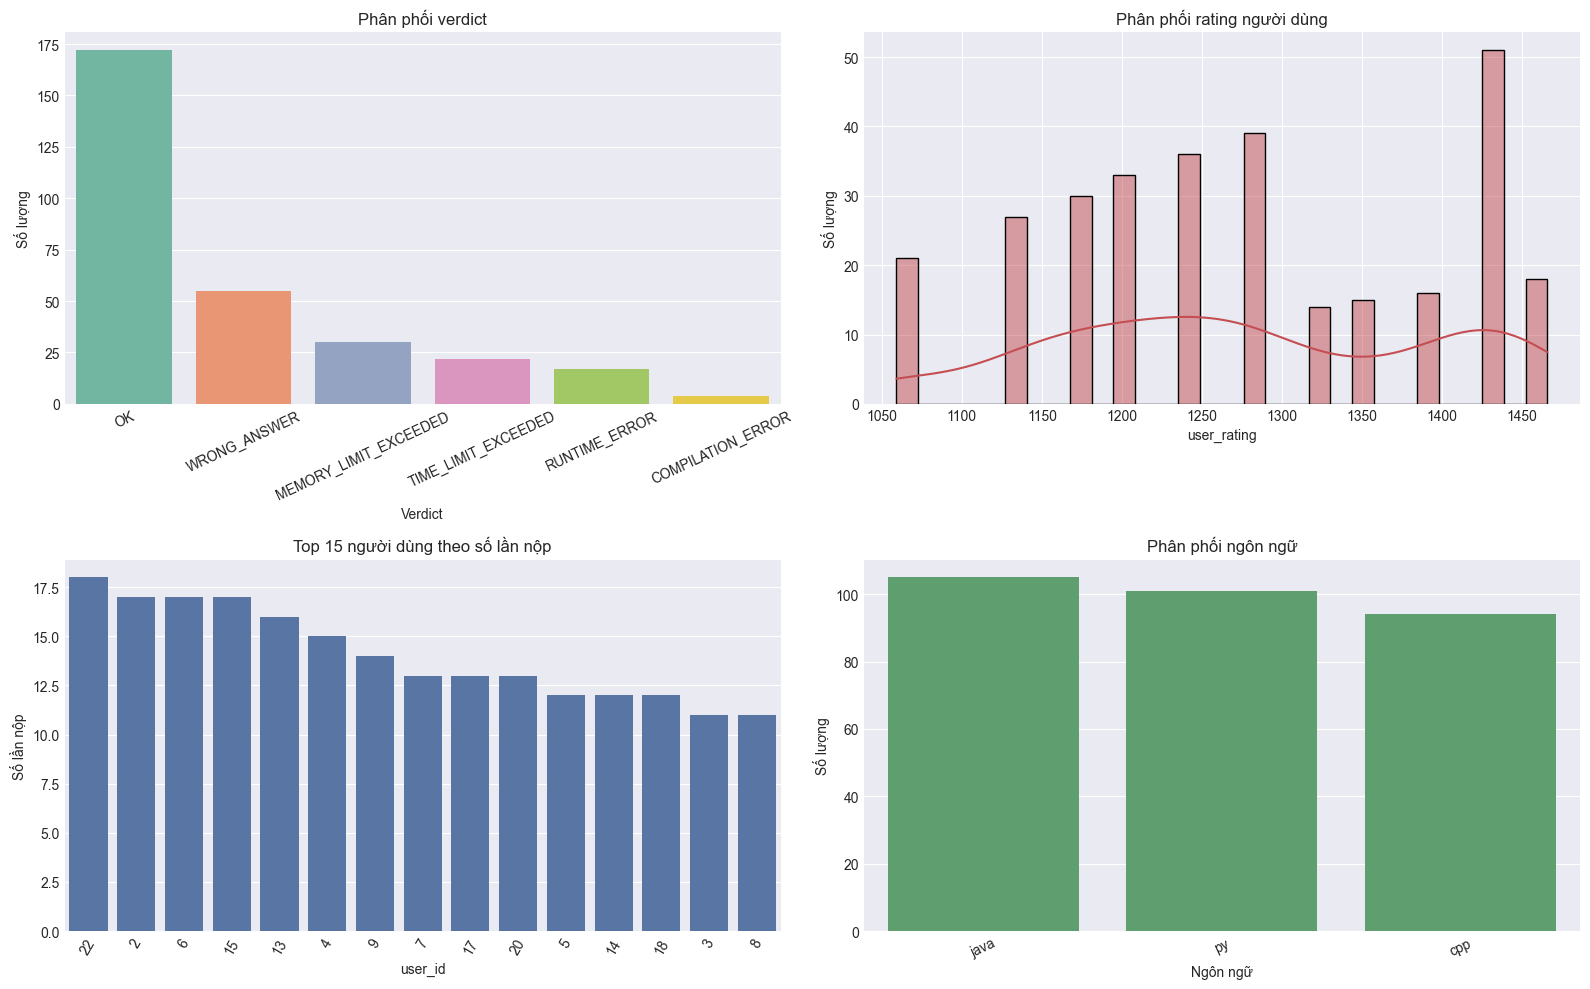

In [50]:
# Trực quan hóa dữ liệu submissions (đầy đủ)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Phân phối verdict
if 'verdict' in submissions_df.columns:
    verdict_counts = submissions_df['verdict'].fillna('UNKNOWN').value_counts().head(12)
    sns.barplot(x=verdict_counts.index, y=verdict_counts.values, ax=axes[0, 0], palette='Set2')
    axes[0, 0].set_title('Phân phối verdict')
    axes[0, 0].set_xlabel('Verdict')
    axes[0, 0].set_ylabel('Số lượng')
    axes[0, 0].tick_params(axis='x', rotation=25)
else:
    axes[0, 0].text(0.5, 0.5, 'Không tìm thấy cột verdict', ha='center', va='center')
    axes[0, 0].set_axis_off()

# 2) Phân phối rating người dùng
if 'user_rating' in submissions_df.columns:
    sns.histplot(submissions_df['user_rating'].dropna(), bins=30, kde=True, ax=axes[0, 1], color='#C44E52')
    axes[0, 1].set_title('Phân phối rating người dùng')
    axes[0, 1].set_xlabel('user_rating')
    axes[0, 1].set_ylabel('Số lượng')
else:
    axes[0, 1].text(0.5, 0.5, 'Không tìm thấy cột user_rating', ha='center', va='center')
    axes[0, 1].set_axis_off()

# 3) Top người dùng theo số lần nộp
if 'user_id' in submissions_df.columns:
    top_users = submissions_df['user_id'].value_counts().head(15)
    sns.barplot(x=top_users.index.astype(str), y=top_users.values, ax=axes[1, 0], color='#4C72B0')
    axes[1, 0].set_title('Top 15 người dùng theo số lần nộp')
    axes[1, 0].set_xlabel('user_id')
    axes[1, 0].set_ylabel('Số lần nộp')
    axes[1, 0].tick_params(axis='x', rotation=60)
else:
    axes[1, 0].text(0.5, 0.5, 'Không tìm thấy cột user_id', ha='center', va='center')
    axes[1, 0].set_axis_off()

# 4) Phân phối ngôn ngữ
if 'language' in submissions_df.columns:
    lang_counts = submissions_df['language'].fillna('unknown').value_counts().head(10)
    sns.barplot(x=lang_counts.index, y=lang_counts.values, ax=axes[1, 1], color='#55A868')
    axes[1, 1].set_title('Phân phối ngôn ngữ')
    axes[1, 1].set_xlabel('Ngôn ngữ')
    axes[1, 1].set_ylabel('Số lượng')
    axes[1, 1].tick_params(axis='x', rotation=25)
else:
    axes[1, 1].text(0.5, 0.5, 'Không tìm thấy cột language', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

## 3. Gộp dữ liệu và tiền xử lý

Số bài đã ánh xạ rating: 7908 problems
Người dùng có >= 10 submissions: 19 out of 25
   Số submissions còn lại: 252

Thống kê dữ liệu sau làm sạch:
Tổng số submissions: 252
Số người dùng duy nhất: 19
Số bài toán duy nhất: 7
Tỷ lệ accepted: 55.16%

Một vài bản ghi sau làm sạch:
   user_id  user_rating problem_id  problem_rating                verdict  \
0       24         1207         F1            1000    TIME_LIMIT_EXCEEDED   
1        3         1207         F1            1000           WRONG_ANSWER   
2       20         1281         F1            1000  MEMORY_LIMIT_EXCEEDED   
3       15         1429         F1            1000           WRONG_ANSWER   
4        4         1355         F1            1000           WRONG_ANSWER   
5        9         1318         F1            1000          RUNTIME_ERROR   
6       15         1429         F1            1000  MEMORY_LIMIT_EXCEEDED   
7        7         1281          E            1000    TIME_LIMIT_EXCEEDED   
8       12         1170      

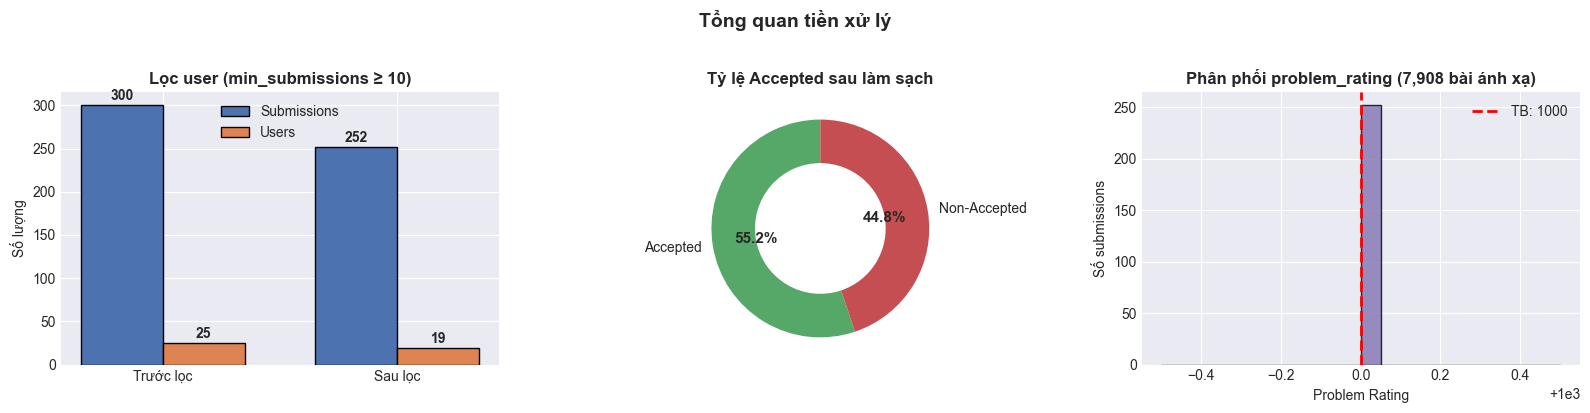

In [51]:
# Bước 1: Trích xuất rating bài toán từ dữ liệu
problem_ratings = {}

if 'contest' in problems_df.columns and 'problem_name' in problems_df.columns:
    if 'problem_tags' in problems_df.columns:
        for _, row in problems_df.iterrows():
            try:
                prob_id = str(row['contest']) + '_' + str(row['problem_name']).split()[0]
                tags = str(row['problem_tags'])
                if '*' in tags:
                    rating = int(tags.split('*')[1].split()[0])
                else:
                    rating = 1000
                problem_ratings[prob_id] = rating
            except Exception:
                pass

if not problem_ratings:
    for problem in submissions_df['problem_id'].unique():
        problem_ratings[problem] = np.random.choice(range(800, 3000, 100))

print(f"Số bài đã ánh xạ rating: {len(problem_ratings)} problems")

# Bước 2: Lọc người dùng có số lần nộp tối thiểu
min_submissions = 10
user_submission_counts = submissions_df.groupby('user_id').size()
valid_users = user_submission_counts[user_submission_counts >= min_submissions].index.tolist()

data_cleaned = submissions_df[submissions_df['user_id'].isin(valid_users)].copy()
print(f"Người dùng có >= {min_submissions} submissions: {len(valid_users)} out of {submissions_df['user_id'].nunique()}")
print(f"   Số submissions còn lại: {len(data_cleaned)}")

# Bước 3: Thêm rating bài toán
data_cleaned['problem_rating'] = data_cleaned['problem_id'].map(lambda x: problem_ratings.get(x, 1000))

# Bước 4: Mã hóa verdict (1 = accepted, 0 = không accepted)
accepted_tokens = {'AC', 'OK', 'ACCEPTED'}
data_cleaned['verdict_norm'] = data_cleaned['verdict'].astype(str).str.upper().str.strip()
data_cleaned['is_accepted'] = data_cleaned['verdict_norm'].isin(accepted_tokens).astype(int)

# Bước 5: Sắp xếp theo timestamp để theo dõi lịch sử đúng thứ tự
data_cleaned = data_cleaned.sort_values('timestamp').reset_index(drop=True)

print(f"\nThống kê dữ liệu sau làm sạch:")
print(f"Tổng số submissions: {len(data_cleaned)}")
print(f"Số người dùng duy nhất: {data_cleaned['user_id'].nunique()}")
print(f"Số bài toán duy nhất: {data_cleaned['problem_id'].nunique()}")
print(f"Tỷ lệ accepted: {data_cleaned['is_accepted'].mean():.2%}")
print(f"\nMột vài bản ghi sau làm sạch:")
print(data_cleaned[['user_id', 'user_rating', 'problem_id', 'problem_rating', 'verdict', 'is_accepted']].head(10))

# --- Trực quan hóa quá trình tiền xử lý ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Tổng quan tiền xử lý', fontsize=14, fontweight='bold', y=1.02)

# 1) Trước vs Sau lọc user
before_after = ['Trước lọc', 'Sau lọc']
ba_users = [submissions_df['user_id'].nunique(), data_cleaned['user_id'].nunique()]
ba_subs  = [len(submissions_df), len(data_cleaned)]

x_ba = np.arange(len(before_after))
w = 0.35
axes[0].bar(x_ba - w/2, ba_subs, w, label='Submissions', color='#4C72B0', edgecolor='black')
axes[0].bar(x_ba + w/2, ba_users, w, label='Users', color='#DD8452', edgecolor='black')
axes[0].set_xticks(x_ba)
axes[0].set_xticklabels(before_after)
for i, (s, u) in enumerate(zip(ba_subs, ba_users)):
    axes[0].text(i - w/2, s + max(ba_subs)*0.02, str(s), ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + w/2, u + max(ba_subs)*0.02, str(u), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title(f'Lọc user (min_submissions ≥ {min_submissions})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng')
axes[0].legend()

# 2) Tỷ lệ accepted (donut chart)
acc_rate = data_cleaned['is_accepted'].mean()
non_rate = 1 - acc_rate
wedges, texts, autotexts = axes[1].pie(
    [acc_rate, non_rate], labels=['Accepted', 'Non-Accepted'],
    autopct='%1.1f%%', colors=['#55A868', '#C44E52'],
    startangle=90, wedgeprops=dict(width=0.4))
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[1].set_title('Tỷ lệ Accepted sau làm sạch', fontsize=12, fontweight='bold')

# 3) Phân phối problem_rating đã ánh xạ
ratings_mapped = data_cleaned['problem_rating'].dropna()
axes[2].hist(ratings_mapped, bins=20, color='#8172B2', edgecolor='black', alpha=0.8)
axes[2].axvline(ratings_mapped.mean(), color='red', linestyle='--', linewidth=2,
                label=f'TB: {ratings_mapped.mean():.0f}')
axes[2].set_title(f'Phân phối problem_rating ({len(problem_ratings):,} bài ánh xạ)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Problem Rating')
axes[2].set_ylabel('Số submissions')
axes[2].legend()

plt.tight_layout()
plt.show()

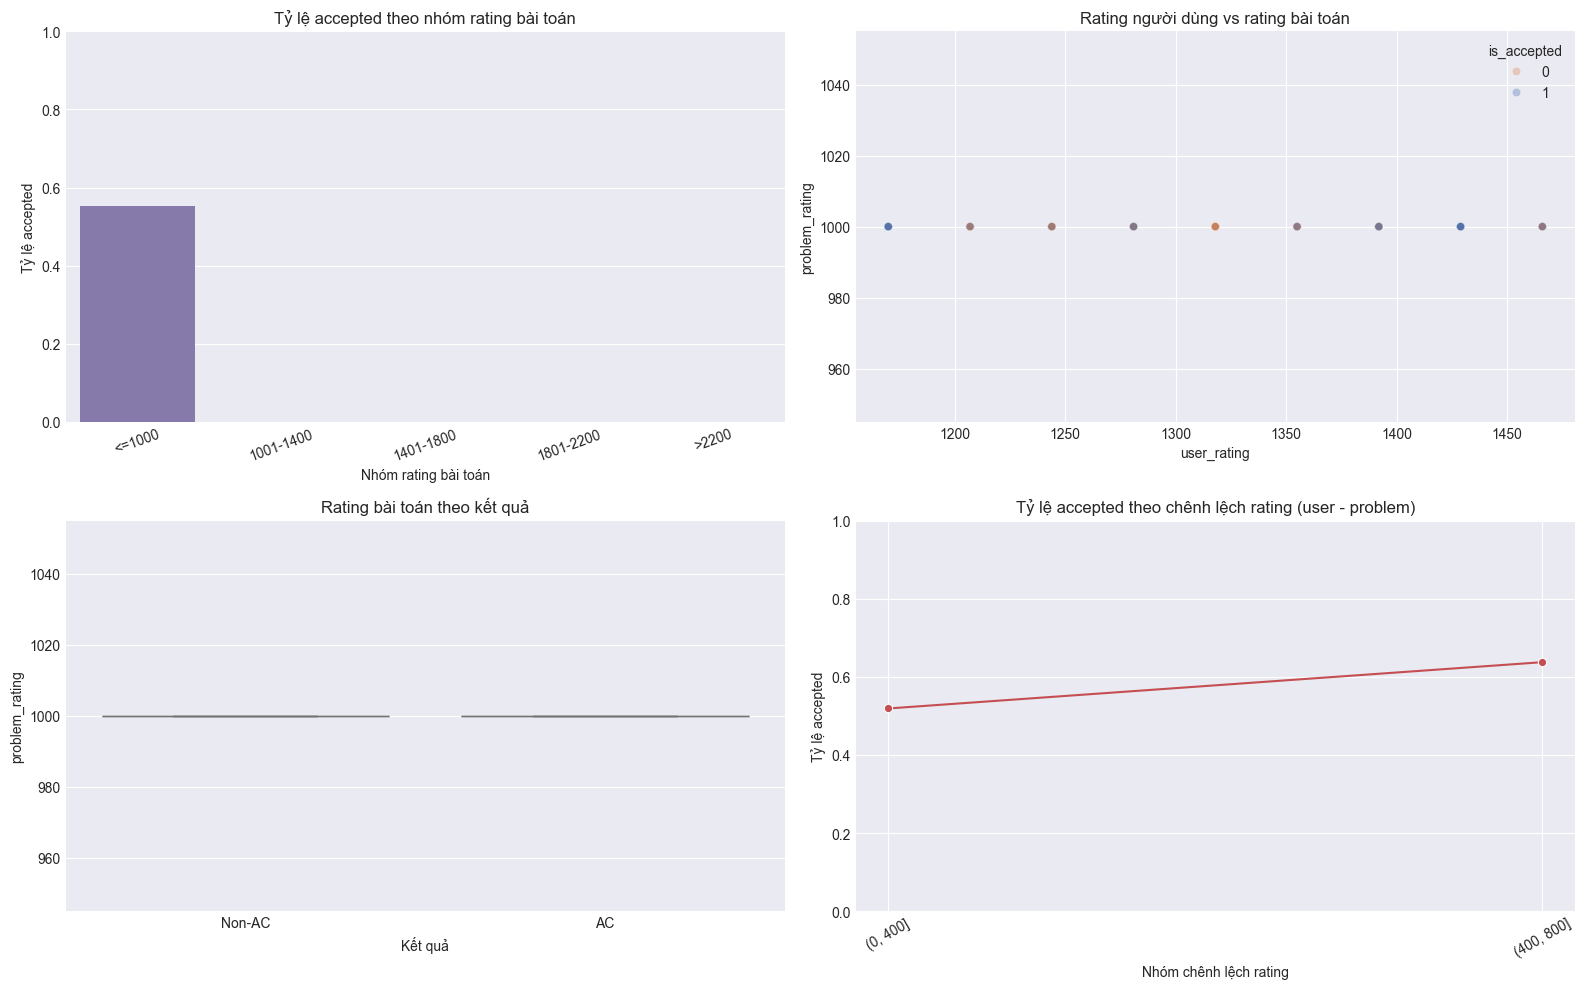

In [52]:
# Trực quan hóa dữ liệu gộp/làm sạch (đầy đủ)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_df = data_cleaned.copy()

# 1) Tỷ lệ accepted theo nhóm rating bài toán
plot_df['rating_bin'] = pd.cut(
    plot_df['problem_rating'],
    bins=[0, 1000, 1400, 1800, 2200, 4000],
    labels=['<=1000', '1001-1400', '1401-1800', '1801-2200', '>2200']
)
acc_by_bin = plot_df.groupby('rating_bin', observed=False)['is_accepted'].mean().reset_index()
sns.barplot(data=acc_by_bin, x='rating_bin', y='is_accepted', ax=axes[0, 0], color='#8172B2')
axes[0, 0].set_title('Tỷ lệ accepted theo nhóm rating bài toán')
axes[0, 0].set_xlabel('Nhóm rating bài toán')
axes[0, 0].set_ylabel('Tỷ lệ accepted')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(axis='x', rotation=20)

# 2) Rating người dùng vs rating bài toán (tô màu theo accepted)
sample_n = min(5000, len(plot_df))
plot_sample = plot_df.sample(n=sample_n, random_state=42) if len(plot_df) > sample_n else plot_df
sns.scatterplot(
    data=plot_sample,
    x='user_rating',
    y='problem_rating',
    hue='is_accepted',
    alpha=0.35,
    palette={0: '#DD8452', 1: '#4C72B0'},
    ax=axes[0, 1]
)
axes[0, 1].set_title('Rating người dùng vs rating bài toán')
axes[0, 1].set_xlabel('user_rating')
axes[0, 1].set_ylabel('problem_rating')

# 3) Phân phối rating bài toán theo kết quả
plot_df['result'] = np.where(plot_df['is_accepted'] == 1, 'AC', 'Non-AC')
sns.boxplot(data=plot_df, x='result', y='problem_rating', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Rating bài toán theo kết quả')
axes[1, 0].set_xlabel('Kết quả')
axes[1, 0].set_ylabel('problem_rating')

# 4) Chênh lệch rating (user - problem) theo accepted
plot_df['rating_gap'] = plot_df['user_rating'] - plot_df['problem_rating']
gap_bins = pd.cut(plot_df['rating_gap'], bins=[-3000, -800, -400, 0, 400, 800, 3000])
gap_stats = plot_df.groupby(gap_bins, observed=False)['is_accepted'].mean().reset_index()
gap_stats['gap_bin'] = gap_stats['rating_gap'].astype(str)
sns.lineplot(data=gap_stats, x='gap_bin', y='is_accepted', marker='o', ax=axes[1, 1], color='#C44E52')
axes[1, 1].set_title('Tỷ lệ accepted theo chênh lệch rating (user - problem)')
axes[1, 1].set_xlabel('Nhóm chênh lệch rating')
axes[1, 1].set_ylabel('Tỷ lệ accepted')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Tạo đặc trưng


Đặc trưng mẫu của người dùng:
Người dùng 24: {'accuracy': np.float64(0.4), 'streak': 2, 'rating': np.int64(1207), 'user_id': np.int64(24), 'recent_ac': 4, 'recent_total': 10}
Người dùng 3: {'accuracy': np.float64(0.5), 'streak': 0, 'rating': np.int64(1207), 'user_id': np.int64(3), 'recent_ac': 5, 'recent_total': 10}
Người dùng 20: {'accuracy': np.float64(0.7), 'streak': 1, 'rating': np.int64(1281), 'user_id': np.int64(20), 'recent_ac': 7, 'recent_total': 10}
Người dùng 15: {'accuracy': np.float64(0.9), 'streak': 4, 'rating': np.int64(1429), 'user_id': np.int64(15), 'recent_ac': 9, 'recent_total': 10}
Người dùng 4: {'accuracy': np.float64(0.7), 'streak': 1, 'rating': np.int64(1355), 'user_id': np.int64(4), 'recent_ac': 7, 'recent_total': 10}

Đã tính trạng thái cho 19 người dùng

Thống kê đặc trưng:
Accuracy - Trung bình: 0.60, Độ lệch chuẩn: 0.19
Streak - Trung bình: 1.58, Tối đa: 9
Rating - Trung bình: 1291, Khoảng: [1170, 1466]


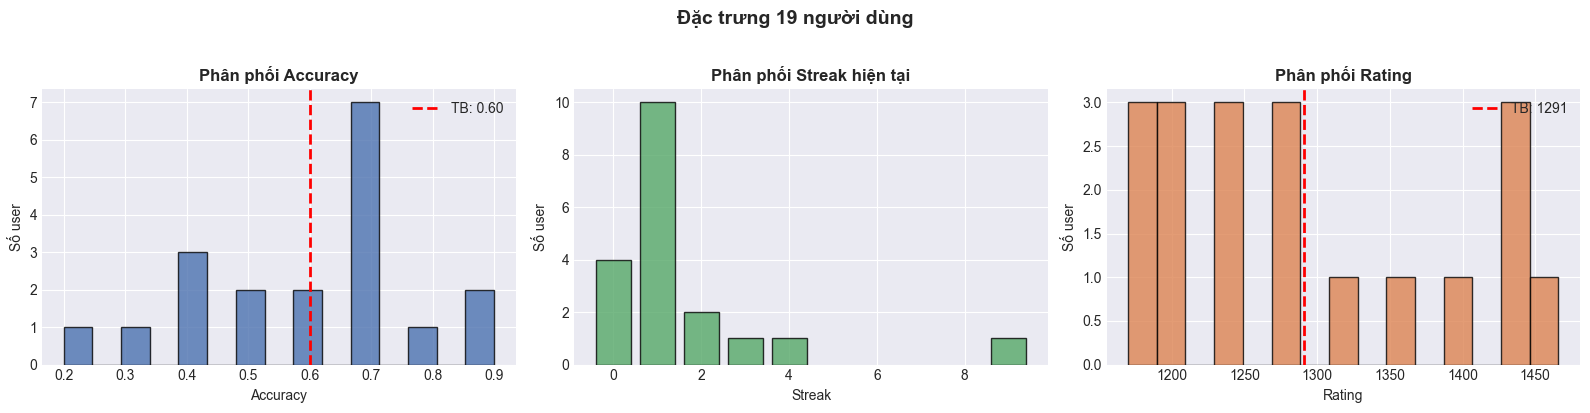

In [53]:
def calculate_user_features(user_id, data_df, window_size=10):
    """
    Tính đặc trưng của người dùng dựa trên lịch sử nộp gần đây.
    
    Tham số:
        user_id: ID người dùng
        data_df: DataFrame dữ liệu nộp bài
        window_size: số bài nộp gần đây để xem xét
    
    Trả về:
        dict: đặc trưng gồm accuracy, streak, rating
    """
    user_submissions = data_df[data_df['user_id'] == user_id].tail(window_size)
    
    if len(user_submissions) == 0:
        return {'accuracy': 0.5, 'streak': 0, 'rating': 1000, 'user_id': user_id}
    
    # Tính accuracy trong các bài nộp gần đây
    accuracy = user_submissions['is_accepted'].mean()
    
    # Tính streak hiện tại (số bài AC liên tiếp)
    verdicts = user_submissions['is_accepted'].values
    current_streak = 0
    for v in reversed(verdicts):
        if v == 1:
            current_streak += 1
        else:
            break
    
    # Lấy rating người dùng
    rating = user_submissions['user_rating'].iloc[-1] if len(user_submissions) > 0 else 1000
    
    return {
        'accuracy': accuracy,
        'streak': current_streak,
        'rating': rating,
        'user_id': user_id,
        'recent_ac': int(user_submissions['is_accepted'].sum()),
        'recent_total': len(user_submissions)
    }

# Kiểm tra tính đặc trưng
print("\nĐặc trưng mẫu của người dùng:")
test_users = data_cleaned['user_id'].unique()[:5]
for user_id in test_users:
    features = calculate_user_features(user_id, data_cleaned)
    print(f"Người dùng {user_id}: {features}")

# Tạo snapshot trạng thái người dùng để huấn luyện
user_states = {}
for user_id in data_cleaned['user_id'].unique():
    user_states[user_id] = calculate_user_features(user_id, data_cleaned)

print(f"\nĐã tính trạng thái cho {len(user_states)} người dùng")

# Thống kê đặc trưng
accuracies = [s['accuracy'] for s in user_states.values()]
streaks = [s['streak'] for s in user_states.values()]
ratings = [s['rating'] for s in user_states.values()]

print(f"\nThống kê đặc trưng:")
print(f"Accuracy - Trung bình: {np.mean(accuracies):.2f}, Độ lệch chuẩn: {np.std(accuracies):.2f}")
print(f"Streak - Trung bình: {np.mean(streaks):.2f}, Tối đa: {max(streaks)}")
print(f"Rating - Trung bình: {np.mean(ratings):.0f}, Khoảng: [{min(ratings)}, {max(ratings)}]")

# --- Trực quan hóa đặc trưng người dùng ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle(f'Đặc trưng {len(user_states)} người dùng', fontsize=14, fontweight='bold', y=1.02)

# 1) Phân phối accuracy
axes[0].hist(accuracies, bins=15, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(accuracies), color='red', linestyle='--', linewidth=2,
                label=f'TB: {np.mean(accuracies):.2f}')
axes[0].set_title('Phân phối Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Số user')
axes[0].legend()

# 2) Phân phối streak
streak_counts = Counter(streaks)
streak_keys = sorted(streak_counts.keys())
axes[1].bar(streak_keys, [streak_counts[k] for k in streak_keys],
            color='#55A868', edgecolor='black', alpha=0.8)
axes[1].set_title('Phân phối Streak hiện tại', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Streak')
axes[1].set_ylabel('Số user')

# 3) Phân phối rating
axes[2].hist(ratings, bins=15, color='#DD8452', edgecolor='black', alpha=0.8)
axes[2].axvline(np.mean(ratings), color='red', linestyle='--', linewidth=2,
                label=f'TB: {np.mean(ratings):.0f}')
axes[2].set_title('Phân phối Rating', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Số user')
axes[2].legend()

plt.tight_layout()
plt.show()

Đang tạo biểu đồ phân bố đặc trưng người dùng...


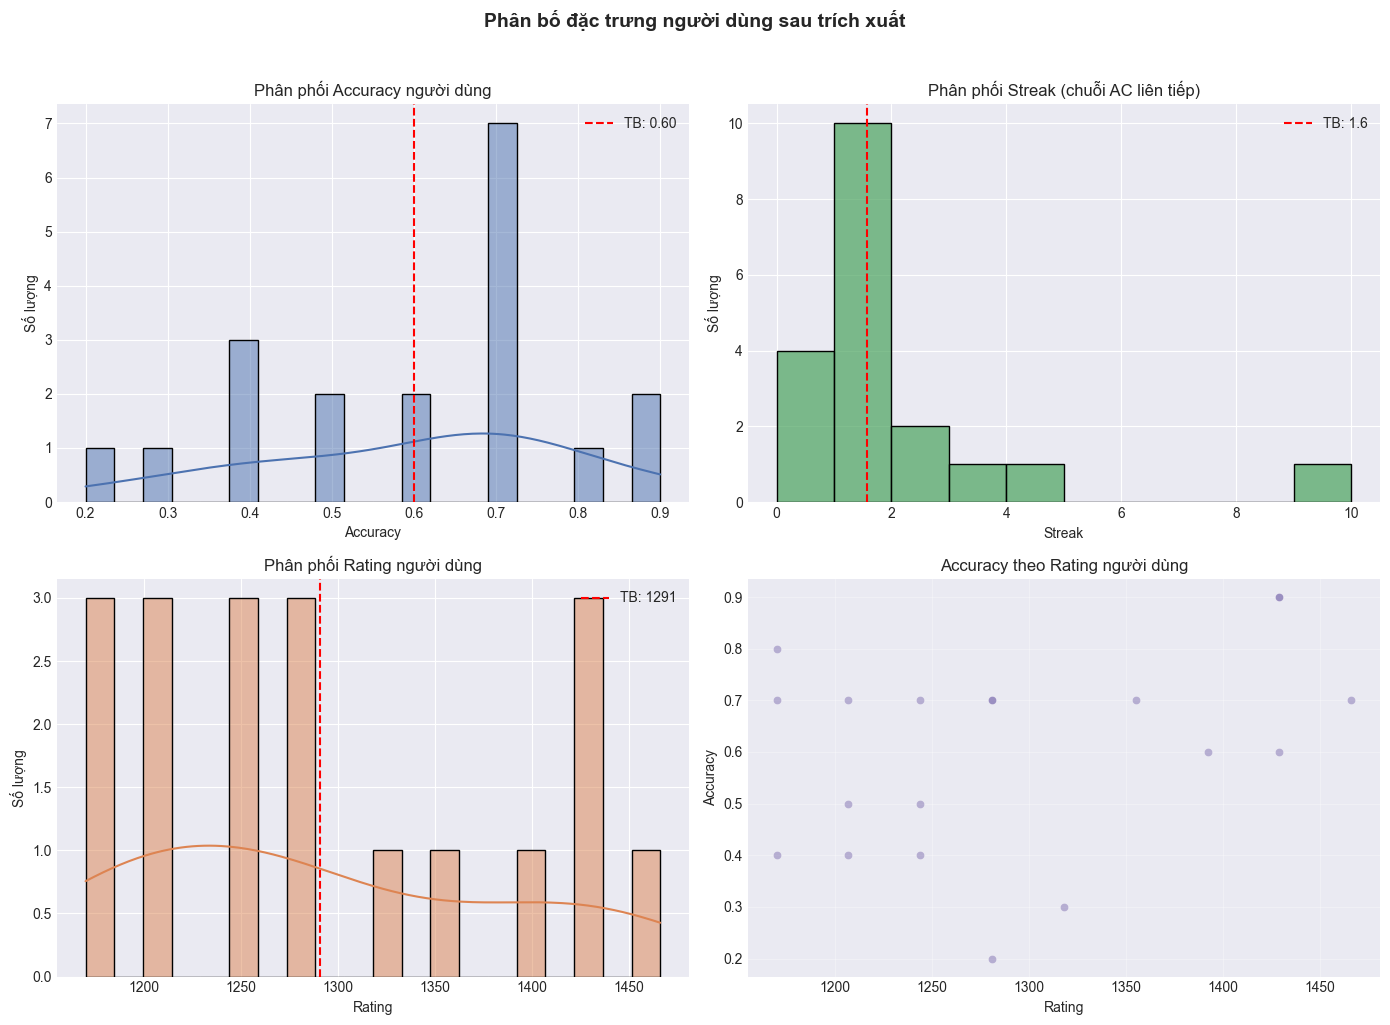

Hoàn tất trực quan hóa đặc trưng!


In [54]:
# Trực quan hóa đặc trưng người dùng
print("Đang tạo biểu đồ phân bố đặc trưng người dùng...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Phân phối Accuracy
sns.histplot(accuracies, bins=20, kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].axvline(np.mean(accuracies), color='red', linestyle='--', label=f'TB: {np.mean(accuracies):.2f}')
axes[0, 0].set_title('Phân phối Accuracy người dùng')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].legend()

# 2) Phân phối Streak
sns.histplot(streaks, bins=range(0, max(streaks)+2), ax=axes[0, 1], color='#55A868')
axes[0, 1].axvline(np.mean(streaks), color='red', linestyle='--', label=f'TB: {np.mean(streaks):.1f}')
axes[0, 1].set_title('Phân phối Streak (chuỗi AC liên tiếp)')
axes[0, 1].set_xlabel('Streak')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].legend()

# 3) Phân phối Rating
sns.histplot(ratings, bins=20, kde=True, ax=axes[1, 0], color='#DD8452')
axes[1, 0].axvline(np.mean(ratings), color='red', linestyle='--', label=f'TB: {np.mean(ratings):.0f}')
axes[1, 0].set_title('Phân phối Rating người dùng')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Số lượng')
axes[1, 0].legend()

# 4) Accuracy vs Rating (scatter)
sns.scatterplot(x=ratings, y=accuracies, alpha=0.5, ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Accuracy theo Rating người dùng')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Phân bố đặc trưng người dùng sau trích xuất', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Hoàn tất trực quan hóa đặc trưng!")

## 5. Cài đặt môi trường (MDP)

In [55]:
    # Ánh xạ hành động: mức độ khó tương ứng khoảng rating bài toán
    ACTION_DIFFICULTY = {
        0: (800, 1200),      # Dễ
        1: (1200, 1800),     # Trung bình
        2: (1800, 3500)      # Khó
    }

    def __init__(self, data_df, problem_ratings_dict, num_rating_buckets=5,
                 num_accuracy_buckets=3, num_streak_buckets=4):
        self.data = data_df
        self.problem_ratings = problem_ratings_dict

        # Tham số bucket hóa
        self.num_rating_buckets = num_rating_buckets
        self.num_accuracy_buckets = num_accuracy_buckets
        self.num_streak_buckets = num_streak_buckets

        # Khoảng rating cho bucket
        self.rating_range = (600, 3500)

        # Tính trước bài toán theo mức độ khó
        self.problems_by_difficulty = {
            0: [],  # Dễ
            1: [],  # Trung bình
            2: []   # Khó
        }

        for prob_id, rating in problem_ratings_dict.items():
            if 800 <= rating < 1200:
                self.problems_by_difficulty[0].append(prob_id)
            elif 1200 <= rating < 1800:
                self.problems_by_difficulty[1].append(prob_id)
            else:
                self.problems_by_difficulty[2].append(prob_id)

    def discretize_state(self, rating, accuracy, streak):
        """Chuyển trạng thái liên tục thành các bucket rời rạc."""
        rating_bucket = int(np.clip(
            (rating - self.rating_range[0]) / (self.rating_range[1] - self.rating_range[0]) * (self.num_rating_buckets - 1),
            0, self.num_rating_buckets - 1
        ))

        accuracy_bucket = int(accuracy * (self.num_accuracy_buckets - 1))
        accuracy_bucket = np.clip(accuracy_bucket, 0, self.num_accuracy_buckets - 1)

        streak_bucket = min(streak, self.num_streak_buckets - 1)

        return (rating_bucket, accuracy_bucket, streak_bucket)

    def get_success_probability(self, user_rating, problem_rating):
        """Tính xác suất P(AC) bằng hàm logistic."""
        diff = user_rating - problem_rating
        return expit(0.002 * diff)

    def take_action(self, action, user_state):
        """
        Thực thi hành động và trả về kết quả chuyển trạng thái.

        Trả về:
            reward, new_state, is_success, problem_id, problem_rating
        """
        available_problems = self.problems_by_difficulty.get(action, [])
        if not available_problems:
            available_problems = list(self.problem_ratings.keys())

        problem_id = np.random.choice(available_problems)
        problem_rating = self.problem_ratings[problem_id]

        p_success = self.get_success_probability(user_state['rating'], problem_rating)
        is_success = np.random.random() < p_success

        # Phần thưởng có xét vùng phát triển gần nhất (ZPD)
        rating_gap = abs(user_state['rating'] - problem_rating)
        if is_success:
            base_reward = 1 + action  # Dễ=1, TB=2, Khó=3
            # Thưởng thêm khi bài ở gần trình độ người dùng (ZPD)
            zpd_bonus = 0.5 if rating_gap < 400 else 0.0
            reward = base_reward + zpd_bonus
        else:
            # Phạt nặng hơn khi chọn bài quá khó so với trình độ
            reward = -1 - (action * 0.3)

        old_accuracy = user_state['accuracy']
        old_streak = user_state['streak']

        if is_success:
            new_accuracy = (old_accuracy * 9 + 1) / 10
            new_streak = old_streak + 1
            # Rating tăng tương xứng với độ khó bài (Dễ=+2, TB=+5, Khó=+8)
            rating_change = 2 + action * 3
        else:
            new_accuracy = (old_accuracy * 9 + 0) / 10
            new_streak = 0
            # Rating giảm tương xứng (Dễ=-1, TB=-2.5, Khó=-4)
            rating_change = -(1 + action * 1.5)

        new_state = {
            'rating': user_state['rating'] + rating_change,
            'accuracy': new_accuracy,
            'streak': new_streak,
            'user_id': user_state['user_id']
        }

        return reward, new_state, is_success, problem_id, problem_rating

# Khởi tạo môi trường
env = ProgrammingExerciseEnv(data_cleaned, problem_ratings)
print("  Đã tạo môi trường")
print(f"   Số bucket rating: {env.num_rating_buckets}")
print(f"   Số bucket accuracy: {env.num_accuracy_buckets}")
print(f"   Số bucket streak: {env.num_streak_buckets}")
print(f"   Tổng số trạng thái: {env.num_rating_buckets * env.num_accuracy_buckets * env.num_streak_buckets}")
print("\nSố bài theo mức độ khó:")
for diff in [0, 1, 2]:
    diff_names = {0: 'Dễ', 1: 'Trung bình', 2: 'Khó'}
    print(f"   {diff_names[diff]} (level {diff}): {len(env.problems_by_difficulty[diff])} bài")

# --- Trực quan hóa môi trường RL ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Tổng quan Môi trường RL', fontsize=14, fontweight='bold', y=1.02)

# 1) Số bài theo mức độ khó
diff_names = {0: 'Dễ\n(800-1200)', 1: 'Trung bình\n(1200-1800)', 2: 'Khó\n(1800+)'}
diff_counts = [len(env.problems_by_difficulty[d]) for d in [0, 1, 2]]
colors = ['#55A868', '#DD8452', '#C44E52']
bars = axes[0].bar(list(diff_names.values()), diff_counts, color=colors, edgecolor='black')
for bar, val in zip(bars, diff_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(diff_counts)*0.02,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Số bài theo mức độ khó', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số bài toán')

# 2) Cấu trúc bucket (state space)
bucket_names = ['Rating', 'Accuracy', 'Streak']
bucket_sizes = [env.num_rating_buckets, env.num_accuracy_buckets, env.num_streak_buckets]
bars2 = axes[1].bar(bucket_names, bucket_sizes, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
for bar, val in zip(bars2, bucket_sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title(f'Kích thước bucket (tổng: {np.prod(bucket_sizes)} trạng thái)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số bucket')

# 3) Hàm reward theo action & kết quả
actions = [0, 1, 2]
reward_ac = [1 + a + 0.5 for a in actions]  # AC + ZPD bonus
reward_wa = [-1 - a * 0.3 for a in actions]
w = 0.35
x_act = np.arange(len(actions))
axes[2].bar(x_act - w/2, reward_ac, w, label='AC (+ ZPD)', color='#55A868', edgecolor='black')
axes[2].bar(x_act + w/2, reward_wa, w, label='WA', color='#C44E52', edgecolor='black')
axes[2].set_xticks(x_act)
axes[2].set_xticklabels(['Dễ', 'Trung bình', 'Khó'])
axes[2].set_title('Cấu trúc phần thưởng', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Reward')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

IndentationError: unexpected indent (2702039396.py, line 2)

Đang trực quan hóa cấu trúc môi trường...


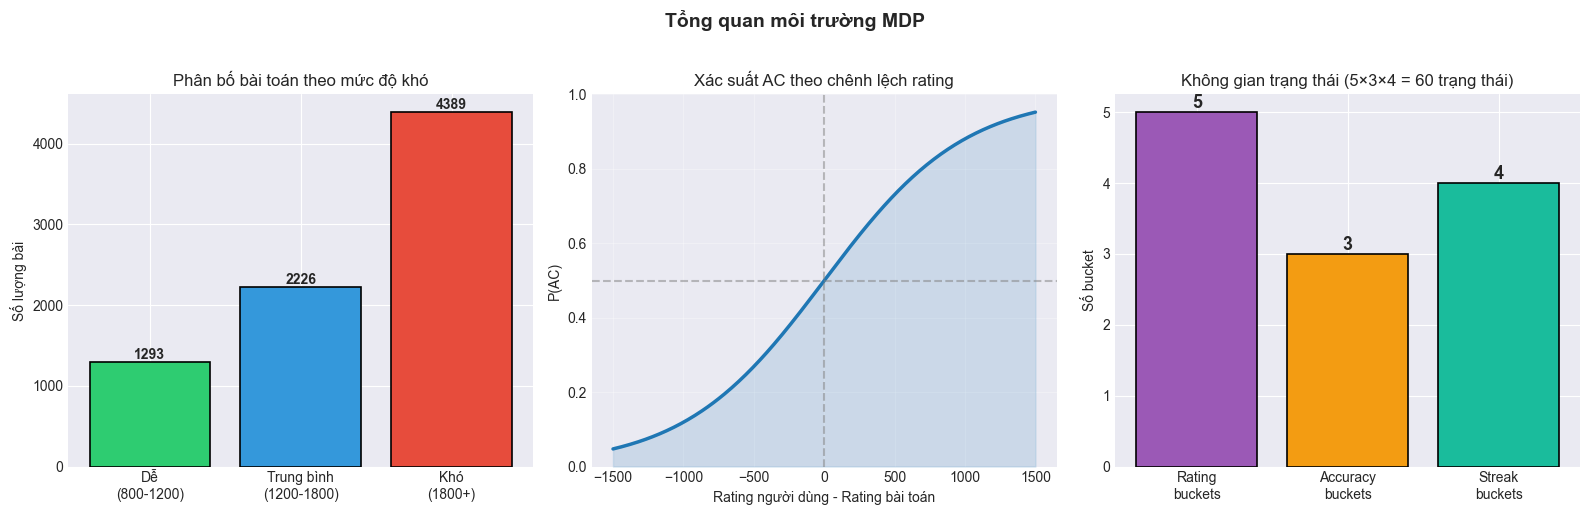

Hoàn tất trực quan hóa môi trường!


In [ ]:
# Trực quan hóa cấu trúc môi trường MDP
print("Đang trực quan hóa cấu trúc môi trường...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Số bài theo mức độ khó
diff_names = ['Dễ\n(800-1200)', 'Trung bình\n(1200-1800)', 'Khó\n(1800+)']
diff_counts = [len(env.problems_by_difficulty[i]) for i in range(3)]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[0].bar(diff_names, diff_counts, color=colors, edgecolor='black', linewidth=1.2)
for bar, count in zip(bars, diff_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Phân bố bài toán theo mức độ khó')
axes[0].set_ylabel('Số lượng bài')

# 2) Đường cong xác suất P(AC) theo chênh lệch rating
rating_diffs = np.linspace(-1500, 1500, 300)
p_success = expit(0.002 * rating_diffs)
axes[1].plot(rating_diffs, p_success, linewidth=2.5, color='#1f77b4')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(rating_diffs, p_success, alpha=0.15, color='#1f77b4')
axes[1].set_title('Xác suất AC theo chênh lệch rating')
axes[1].set_xlabel('Rating người dùng - Rating bài toán')
axes[1].set_ylabel('P(AC)')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# 3) Sơ đồ không gian trạng thái (heatmap kích thước)
state_dims = {
    'Rating\nbuckets': env.num_rating_buckets,
    'Accuracy\nbuckets': env.num_accuracy_buckets,
    'Streak\nbuckets': env.num_streak_buckets
}
dim_names = list(state_dims.keys())
dim_values = list(state_dims.values())
bars3 = axes[2].bar(dim_names, dim_values, color=['#9b59b6', '#f39c12', '#1abc9c'], edgecolor='black', linewidth=1.2)
for bar, val in zip(bars3, dim_values):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[2].set_title(f'Không gian trạng thái ({env.num_rating_buckets}×{env.num_accuracy_buckets}×{env.num_streak_buckets} = {env.num_rating_buckets * env.num_accuracy_buckets * env.num_streak_buckets} trạng thái)')
axes[2].set_ylabel('Số bucket')

plt.suptitle('Tổng quan môi trường MDP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Hoàn tất trực quan hóa môi trường!")

## 6. Cài đặt tác tử Q-Learning

In [ ]:
print(" Đang cài đặt tác tử Q-Learning...")

class QLearningAgent:
    """
    Tác tử Q-Learning cho bài toán gợi ý bài tập lập trình

    Công thức cập nhật:
    Q(s,a) <- Q(s,a) + alpha * [r + gamma * max(Q(s',a')) - Q(s,a)]
    """

    def __init__(self, env, learning_rate=0.1, discount_factor=0.95, epsilon=1.0):
        self.env = env
        self.alpha = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        # Bảng Q: Q[trạng_thái][hành_động]
        self.q_table = defaultdict(lambda: np.zeros(3))

        # Chỉ số theo episode
        self.episode_rewards = []
        self.episode_success_rates = []

    def select_action(self, state, training=True):
        """Chọn hành động theo chính sách epsilon-greedy."""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, 3)
        return int(np.argmax(self.q_table[state]))

    def update_q_table(self, state, action, reward, next_state):
        """Cập nhật bảng Q theo công thức Q-learning."""
        q_current = self.q_table[state][action]
        q_next_max = np.max(self.q_table[next_state])
        td_error = reward + self.gamma * q_next_max - q_current
        self.q_table[state][action] = q_current + self.alpha * td_error

    def train_episode(self, user_id, max_steps=20, collect_trace=False):
        """
        Huấn luyện một episode và tùy chọn thu toàn bộ trace theo bước.

        Trả về:
            total_reward, success_count, trace
        """
        user_state = user_states.get(user_id, {
            'rating': 1200,
            'accuracy': 0.5,
            'streak': 0,
            'user_id': user_id
        }).copy()

        state = self.env.discretize_state(
            user_state['rating'],
            user_state['accuracy'],
            user_state['streak']
        )

        total_reward = 0
        success_count = 0

        trace = {
            'rating_history': [],
            'accuracy_history': [],
            'difficulty_history': [],
            'problem_rating_history': [],
            'reward_history': [],
            'result_history': []
        }

        for _ in range(max_steps):
            action = self.select_action(state, training=True)
            reward, next_user_state, is_success, _, problem_rating = self.env.take_action(action, user_state)

            next_state = self.env.discretize_state(
                next_user_state['rating'],
                next_user_state['accuracy'],
                next_user_state['streak']
            )

            self.update_q_table(state, action, reward, next_state)

            total_reward += reward
            success_count += int(is_success)

            if collect_trace:
                trace['rating_history'].append(float(next_user_state['rating']))
                trace['accuracy_history'].append(float(next_user_state['accuracy']))
                trace['difficulty_history'].append(int(action))
                trace['problem_rating_history'].append(float(problem_rating))
                trace['reward_history'].append(float(reward))
                trace['result_history'].append('AC' if is_success else 'WA')

            state = next_state
            user_state = next_user_state

        return total_reward, success_count, trace

    def decay_epsilon(self):
        """Giảm epsilon sau mỗi episode (không phải mỗi lần gọi train)."""
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def predict_action(self, state):
        """Dự đoán hành động theo greedy (không khám phá)."""
        return int(np.argmax(self.q_table[state]))

# Tạo tác tử Q-Learning
agent = QLearningAgent(env, learning_rate=0.1, discount_factor=0.95, epsilon=1.0)
print("  Đã tạo tác tử Q-Learning")
print("   Hệ số học (alpha): 0.1")
print("   Hệ số chiết khấu (gamma): 0.95")
print("   Epsilon ban đầu: 1.0")

 Đang cài đặt tác tử Q-Learning...
  Đã tạo tác tử Q-Learning
   Hệ số học (alpha): 0.1
   Hệ số chiết khấu (gamma): 0.95
   Epsilon ban đầu: 1.0


In [ ]:
# Trực quan hóa cấu trúc không gian trạng thái-hành động của Q-Agent
print("Trực quan hóa không gian trạng thái-hành động...")

state_dims = {
    'Rating bucket': list(range(env.num_rating_buckets)),
    'Accuracy bucket': list(range(env.num_accuracy_buckets)),
    'Streak bucket': list(range(env.num_streak_buckets))
}
dim_names = list(state_dims.keys())
dim_values = [len(v) for v in state_dims.values()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) Kích thước từng chiều trạng thái
bars = axes[0].bar(dim_names, dim_values, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('Số bucket mỗi chiều trạng thái')
axes[0].set_ylabel('Số bucket')
for bar, val in zip(bars, dim_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontweight='bold')

# 2) Tổng quan Q-table ban đầu (tất cả = 0)
total_states = np.prod(dim_values)
total_entries = total_states * 3
axes[1].bar(['Tổng trạng thái', 'Số hành động', 'Tổng Q-entries'],
            [total_states, 3, total_entries],
            color=['#4C72B0', '#55A868', '#DD8452'])
axes[1].set_title('Quy mô bảng Q')
axes[1].set_ylabel('Số lượng')

# 3) Xác suất thành công theo rating gap
gaps = np.linspace(-1500, 1500, 200)
probs = expit(0.002 * gaps)
axes[2].plot(gaps, probs, linewidth=2, color='#4C72B0')
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('P(AC) theo chênh lệch rating')
axes[2].set_xlabel('Rating người dùng - Rating bài')
axes[2].set_ylabel('Xác suất AC')
axes[2].fill_between(gaps, probs, alpha=0.15, color='#4C72B0')

plt.tight_layout()
plt.show()

print(f"\n Không gian trạng thái: {dim_values[0]}×{dim_values[1]}×{dim_values[2]} = {total_states} trạng thái")
print(f" Bảng Q ban đầu: {total_entries} giá trị (tất cả = 0)")
print(f" Trạng thái đã khởi tạo trong Q-table: {len(agent.q_table)}")

Trực quan hóa không gian trạng thái-hành động...


AttributeError: 'ProgrammingExerciseEnv' object has no attribute 'rating_bins'

## 7. Huấn luyện tác tử Q-Learning

In [ ]:
print(" Huấn luyện Q-Learning với theo dõi tiến trình đầy đủ...")

# Tham số huấn luyện
num_episodes = 100
num_users_per_episode = 5
max_steps_per_episode = 20

q_learning_rewards = []
q_learning_accuracies = []

# Theo dõi toàn bộ quá trình huấn luyện
training_traces = []

print(f"\nHuấn luyện trong {num_episodes} episode...")
print(f"Số người dùng mỗi episode: {num_users_per_episode}")

for episode in range(num_episodes):
    episode_total_reward = 0
    episode_total_success = 0
    episode_total_steps = 0

    sampled_users = np.random.choice(
        list(user_states.keys()),
        size=min(num_users_per_episode, len(user_states)),
        replace=True
    )

    episode_trace = {
        'episode': episode + 1,
        'rating_history': [],
        'accuracy_history': [],
        'difficulty_history': [],
        'problem_rating_history': [],
        'reward_history': [],
        'result_history': []
    }

    for user_id in sampled_users:
        reward, success_count, trace = agent.train_episode(
            user_id,
            max_steps=max_steps_per_episode,
            collect_trace=True
        )
        episode_total_reward += reward
        episode_total_success += success_count
        episode_total_steps += max_steps_per_episode

        # Gộp trace người dùng vào trace episode
        for key in ['rating_history', 'accuracy_history', 'difficulty_history', 'problem_rating_history', 'reward_history', 'result_history']:
            episode_trace[key].extend(trace[key])

    avg_reward = episode_total_reward / num_users_per_episode
    success_rate = episode_total_success / episode_total_steps if episode_total_steps > 0 else 0.0

    # Giảm epsilon một lần cho mỗi episode (không phải mỗi user)
    agent.decay_epsilon()

    q_learning_rewards.append(avg_reward)
    q_learning_accuracies.append(success_rate)
    training_traces.append(episode_trace)

    if (episode + 1) % 20 == 0:
        print(
            f"Episode {episode+1:3d} | Reward TB: {avg_reward:6.2f} | "
            f"Tỷ lệ thành công: {success_rate:.2%} | Epsilon: {agent.epsilon:.4f}"
        )

# Gộp toàn bộ lịch sử cho trực quan hóa
all_rating_history = [v for ep in training_traces for v in ep['rating_history']]
all_accuracy_history = [v for ep in training_traces for v in ep['accuracy_history']]
all_difficulty_history = [v for ep in training_traces for v in ep['difficulty_history']]
all_reward_history = [v for ep in training_traces for v in ep['reward_history']]

print("\n Huấn luyện hoàn tất!")
print(f"   Reward trung bình cuối: {q_learning_rewards[-1]:.2f}")
print(f"   Tỷ lệ thành công cuối: {q_learning_accuracies[-1]:.2%}")
print(f"   Kích thước bảng Q: {len(agent.q_table)} trạng thái duy nhất đã ghé thăm")
print(f"   Số episode đã theo dõi: {len(training_traces)}")
print(f"   Tổng số bước đã theo dõi: {len(all_rating_history)}")

 Huấn luyện Q-Learning với theo dõi tiến trình đầy đủ...

Huấn luyện trong 100 episode...
Số người dùng mỗi episode: 5
Episode  20 | Reward TB:   2.80 | Tỷ lệ thành công: 49.00% | Epsilon: 0.6058
Episode  40 | Reward TB:   4.40 | Tỷ lệ thành công: 50.00% | Epsilon: 0.3670
Episode  60 | Reward TB:   7.20 | Tỷ lệ thành công: 61.00% | Epsilon: 0.2223
Episode  80 | Reward TB:   5.80 | Tỷ lệ thành công: 56.00% | Epsilon: 0.1347
Episode 100 | Reward TB:   8.20 | Tỷ lệ thành công: 63.00% | Epsilon: 0.0816

 Huấn luyện hoàn tất!
   Reward trung bình cuối: 8.20
   Tỷ lệ thành công cuối: 63.00%
   Kích thước bảng Q: 16 trạng thái duy nhất đã ghé thăm
   Số episode đã theo dõi: 100
   Tổng số bước đã theo dõi: 10000


Đang tạo biểu đồ tiến trình huấn luyện...


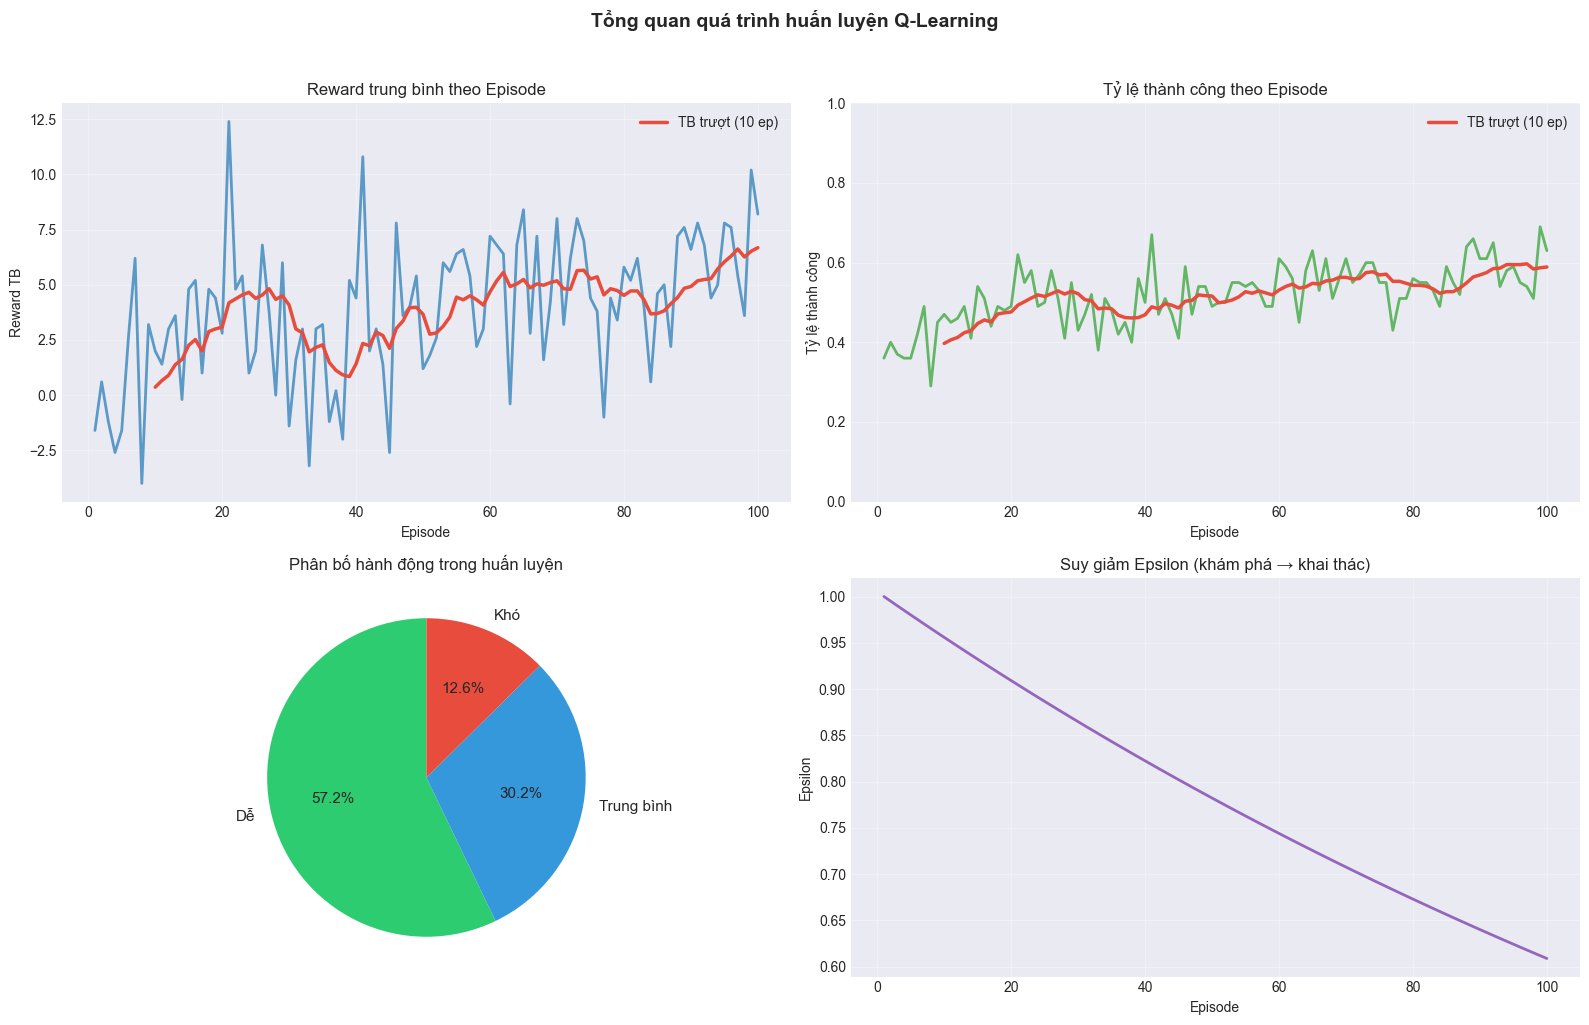

Hoàn tất trực quan hóa huấn luyện!


In [ ]:
# Trực quan hóa quá trình huấn luyện Q-Learning
print("Đang tạo biểu đồ tiến trình huấn luyện...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Đường cong reward theo episode
axes[0, 0].plot(range(1, num_episodes+1), q_learning_rewards, linewidth=2, color='#1f77b4', alpha=0.7)
# Đường trung bình trượt
window = 10
if len(q_learning_rewards) >= window:
    moving_avg = pd.Series(q_learning_rewards).rolling(window=window).mean()
    axes[0, 0].plot(range(1, num_episodes+1), moving_avg, linewidth=2.5, color='#e74c3c', label=f'TB trượt ({window} ep)')
axes[0, 0].set_title('Reward trung bình theo Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Reward TB')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2) Tỷ lệ thành công theo episode
axes[0, 1].plot(range(1, num_episodes+1), q_learning_accuracies, linewidth=2, color='#2ca02c', alpha=0.7)
if len(q_learning_accuracies) >= window:
    moving_avg_acc = pd.Series(q_learning_accuracies).rolling(window=window).mean()
    axes[0, 1].plot(range(1, num_episodes+1), moving_avg_acc, linewidth=2.5, color='#e74c3c', label=f'TB trượt ({window} ep)')
axes[0, 1].set_title('Tỷ lệ thành công theo Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Tỷ lệ thành công')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3) Phân phối hành động trong quá trình huấn luyện
diff_names = {0: 'Dễ', 1: 'Trung bình', 2: 'Khó'}
diff_counter = Counter(all_difficulty_history)
labels = [diff_names[i] for i in range(3)]
values = [diff_counter.get(i, 0) for i in range(3)]
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[1, 0].pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1, 0].set_title('Phân bố hành động trong huấn luyện')

# 4) Suy giảm Epsilon theo episode
epsilons = [1.0]
eps = 1.0
for _ in range(num_episodes - 1):
    eps = max(0.01, eps * 0.995)
    epsilons.append(eps)
axes[1, 1].plot(range(1, num_episodes+1), epsilons, linewidth=2, color='#9467bd')
axes[1, 1].set_title('Suy giảm Epsilon (khám phá → khai thác)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Epsilon')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Tổng quan quá trình huấn luyện Q-Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Hoàn tất trực quan hóa huấn luyện!")

## 8. Chính sách cơ sở

In [ ]:
print(" Đang cài đặt các chính sách cơ sở...")

class RandomPolicy:
    """Chính sách ngẫu nhiên: chọn độ khó đồng đều ngẫu nhiên."""

    def __init__(self, env):
        self.env = env

    def select_action(self, state):
        return np.random.randint(0, 3)

    def train_episode(self, user_id, max_steps=20):
        user_state = user_states.get(user_id, {
            'rating': 1200,
            'accuracy': 0.5,
            'streak': 0,
            'user_id': user_id
        }).copy()

        state = self.env.discretize_state(
            user_state['rating'],
            user_state['accuracy'],
            user_state['streak']
        )

        total_reward = 0
        success_count = 0

        for _ in range(max_steps):
            action = self.select_action(state)
            reward, next_user_state, is_success, _, _ = self.env.take_action(action, user_state)

            next_state = self.env.discretize_state(
                next_user_state['rating'],
                next_user_state['accuracy'],
                next_user_state['streak']
            )

            total_reward += reward
            success_count += int(is_success)

            state = next_state
            user_state = next_user_state

        return total_reward, success_count


class RuleBasedPolicy:
    """Chính sách theo luật: gợi ý dựa trên rating người dùng."""

    def __init__(self, env):
        self.env = env

    def select_action(self, user_rating):
        if user_rating < 1200:
            return 0
        if user_rating < 1800:
            return 1
        return 2

    def train_episode(self, user_id, max_steps=20):
        user_state = user_states.get(user_id, {
            'rating': 1200,
            'accuracy': 0.5,
            'streak': 0,
            'user_id': user_id
        }).copy()

        total_reward = 0
        success_count = 0

        for _ in range(max_steps):
            action = self.select_action(user_state['rating'])
            reward, next_user_state, is_success, _, _ = self.env.take_action(action, user_state)

            total_reward += reward
            success_count += int(is_success)
            user_state = next_user_state

        return total_reward, success_count


random_policy = RandomPolicy(env)
rule_based_policy = RuleBasedPolicy(env)

print(" Đã tạo các chính sách cơ sở")

print("\nĐang huấn luyện chính sách Ngẫu nhiên (Random)...")
random_rewards = []
random_accuracies = []

for episode in range(num_episodes):
    episode_total_reward = 0
    episode_total_success = 0
    episode_total_steps = 0

    sampled_users = np.random.choice(
        list(user_states.keys()),
        size=min(num_users_per_episode, len(user_states)),
        replace=True
    )

    for user_id in sampled_users:
        reward, success_count = random_policy.train_episode(user_id, max_steps=max_steps_per_episode)
        episode_total_reward += reward
        episode_total_success += success_count
        episode_total_steps += max_steps_per_episode

    avg_reward = episode_total_reward / num_users_per_episode
    success_rate = episode_total_success / episode_total_steps if episode_total_steps > 0 else 0.0

    random_rewards.append(avg_reward)
    random_accuracies.append(success_rate)

    if (episode + 1) % 20 == 0:
        print(f"Episode {episode+1:3d} | Reward TB: {avg_reward:6.2f} | Tỷ lệ thành công: {success_rate:.2%}")

print("\nĐang huấn luyện chính sách Theo luật (Rule-Based)...")
rule_based_rewards = []
rule_based_accuracies = []

for episode in range(num_episodes):
    episode_total_reward = 0
    episode_total_success = 0
    episode_total_steps = 0

    sampled_users = np.random.choice(
        list(user_states.keys()),
        size=min(num_users_per_episode, len(user_states)),
        replace=True
    )

    for user_id in sampled_users:
        reward, success_count = rule_based_policy.train_episode(user_id, max_steps=max_steps_per_episode)
        episode_total_reward += reward
        episode_total_success += success_count
        episode_total_steps += max_steps_per_episode

    avg_reward = episode_total_reward / num_users_per_episode
    success_rate = episode_total_success / episode_total_steps if episode_total_steps > 0 else 0.0

    rule_based_rewards.append(avg_reward)
    rule_based_accuracies.append(success_rate)

    if (episode + 1) % 20 == 0:
        print(f"Episode {episode+1:3d} | Reward TB: {avg_reward:6.2f} | Tỷ lệ thành công: {success_rate:.2%}")

print("\n Đã huấn luyện xong tất cả baseline!")

 Đang cài đặt các chính sách cơ sở...
 Đã tạo các chính sách cơ sở

Đang huấn luyện chính sách Ngẫu nhiên (Random)...
Episode  20 | Reward TB:   3.80 | Tỷ lệ thành công: 45.00%
Episode  40 | Reward TB:  -0.20 | Tỷ lệ thành công: 40.00%
Episode  60 | Reward TB:   3.20 | Tỷ lệ thành công: 42.00%
Episode  80 | Reward TB:   0.60 | Tỷ lệ thành công: 43.00%
Episode 100 | Reward TB:   1.60 | Tỷ lệ thành công: 39.00%

Đang huấn luyện chính sách Theo luật (Rule-Based)...
Episode  20 | Reward TB:  -1.40 | Tỷ lệ thành công: 31.00%
Episode  40 | Reward TB:   7.60 | Tỷ lệ thành công: 46.00%
Episode  60 | Reward TB:   2.80 | Tỷ lệ thành công: 46.00%
Episode  80 | Reward TB:   7.40 | Tỷ lệ thành công: 50.00%
Episode 100 | Reward TB:   7.00 | Tỷ lệ thành công: 45.00%

 Đã huấn luyện xong tất cả baseline!


In [ ]:
# Trực quan hóa so sánh reward 3 chính sách sau huấn luyện baseline
print("Trực quan hóa 3 đường cong reward...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Đường cong reward (smoothed)
window = 10
for rewards, label, color in [
    (q_learning_rewards, 'Q-Learning', '#4C72B0'),
    (random_rewards, 'Ngẫu nhiên', '#C44E52'),
    (rule_based_rewards, 'Theo luật', '#8172B2')
]:
    smoothed = pd.Series(rewards).rolling(window, min_periods=1).mean()
    axes[0].plot(smoothed, label=label, linewidth=2, color=color)
    axes[0].fill_between(range(len(rewards)), rewards, alpha=0.08, color=color)

axes[0].set_title(f'Reward trung bình theo episode (trung bình trượt {window})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward trung bình')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2) Accuracy trung bình (smoothed)
for accs, label, color in [
    (q_learning_accuracies, 'Q-Learning', '#4C72B0'),
    (random_accuracies, 'Ngẫu nhiên', '#C44E52'),
    (rule_based_accuracies, 'Theo luật', '#8172B2')
]:
    smoothed = pd.Series(accs).rolling(window, min_periods=1).mean()
    axes[1].plot(smoothed, label=label, linewidth=2, color=color)

axes[1].set_title(f'Tỷ lệ thành công theo episode (trung bình trượt {window})')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Tỷ lệ thành công')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('So sánh 3 chính sách sau huấn luyện', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Box plot so sánh nửa cuối (episode 51-100)
fig2, ax2 = plt.subplots(figsize=(8, 4))
box_data = [q_learning_rewards[50:], random_rewards[50:], rule_based_rewards[50:]]
bp = ax2.boxplot(box_data, labels=['Q-Learning', 'Ngẫu nhiên', 'Theo luật'], patch_artist=True)
colors = ['#4C72B0', '#C44E52', '#8172B2']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_title('Phân phối reward (episode 51-100)')
ax2.set_ylabel('Reward trung bình')
ax2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Hoàn tất trực quan hóa so sánh baseline!")

## 9. Đánh giá và so sánh

In [ ]:
    'avg_reward': np.mean(rule_based_rewards[50:]),
        'std_reward': np.std(rule_based_rewards[50:]),
        'avg_accuracy': np.mean(rule_based_accuracies[50:]),
        'std_accuracy': np.std(rule_based_accuracies[50:]),
        'final_reward': rule_based_rewards[-1],
        'final_accuracy': rule_based_accuracies[-1]
    }
}

print("\n" + "="*80)
print("SO SÁNH HIỆU NĂNG CHÍNH SÁCH (Episode 51-100)")
print("="*80)
print(f"{'Chỉ số':<25} {'Q-Learning':<20} {'Ngẫu nhiên':<20} {'Theo luật':<15}")
print("-"*80)

label_map = {'avg_reward': 'Reward TB', 'std_reward': 'Độ lệch chuẩn reward', 'avg_accuracy': 'Accuracy TB', 'std_accuracy': 'Độ lệch chuẩn acc'}

for key in ['avg_reward', 'std_reward', 'avg_accuracy', 'std_accuracy']:
    print(f"{label_map[key]:<25}", end="")
    for policy in ['Q-Learning', 'Random', 'Rule-Based']:
        value = evaluation_results[policy][key]
        if 'accuracy' in key:
            print(f"{value:>18.2%}", end=" ")
        else:
            print(f"{value:>18.4f}", end=" ")
    print()

print("-"*80)
print(f"{'Reward cuối':<25}", end="")
for policy in ['Q-Learning', 'Random', 'Rule-Based']:
    print(f"{evaluation_results[policy]['final_reward']:>18.2f}", end=" ")
print()

print(f"{'Accuracy cuối':<25}", end="")
for policy in ['Q-Learning', 'Random', 'Rule-Based']:
    print(f"{evaluation_results[policy]['final_accuracy']:>18.2%}", end=" ")
print()
print("="*80)

# Tính mức cải thiện
qlearn_vs_random_reward = (evaluation_results['Q-Learning']['final_reward'] - 
                           evaluation_results['Random']['final_reward']) / abs(evaluation_results['Random']['final_reward']) if evaluation_results['Random']['final_reward'] != 0 else 0
qlearn_vs_rule_reward = (evaluation_results['Q-Learning']['final_reward'] - 
                         evaluation_results['Rule-Based']['final_reward']) / abs(evaluation_results['Rule-Based']['final_reward']) if evaluation_results['Rule-Based']['final_reward'] != 0 else 0

qlearn_vs_random_acc = (evaluation_results['Q-Learning']['final_accuracy'] - 
                        evaluation_results['Random']['final_accuracy']) / abs(evaluation_results['Random']['final_accuracy']) if evaluation_results['Random']['final_accuracy'] != 0 else 0
qlearn_vs_rule_acc = (evaluation_results['Q-Learning']['final_accuracy'] - 
                      evaluation_results['Rule-Based']['final_accuracy']) / abs(evaluation_results['Rule-Based']['final_accuracy']) if evaluation_results['Rule-Based']['final_accuracy'] != 0 else 0

print("\n Mức cải thiện của Q-Learning so với baseline:")
print(f"  so với Ngẫu nhiên:  Reward {qlearn_vs_random_reward:+.2%}, Accuracy {qlearn_vs_random_acc:+.2%}")
print(f"  so với Theo luật:   Reward {qlearn_vs_rule_reward:+.2%}, Accuracy {qlearn_vs_rule_acc:+.2%}")

# --- Trực quan hóa đánh giá ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plt.suptitle('Đánh giá hiệu năng các chính sách', fontsize=14, fontweight='bold', y=1.02)

policies_vi = ['Q-Learning', 'Ngẫu nhiên', 'Theo luật']
policy_keys_eval = ['Q-Learning', 'Random', 'Rule-Based']
colors_eval = ['#4C72B0', '#C44E52', '#8172B2']

# 1) Reward TB ± std
avg_rews = [evaluation_results[p]['avg_reward'] for p in policy_keys_eval]
std_rews = [evaluation_results[p]['std_reward'] for p in policy_keys_eval]
axes[0].bar(policies_vi, avg_rews, yerr=std_rews, capsize=5,
            color=colors_eval, edgecolor='black', linewidth=0.8)
axes[0].set_title('Reward TB ± Std (ep 51-100)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Reward')
for i, (v, s) in enumerate(zip(avg_rews, std_rews)):
    axes[0].text(i, v + s + max(avg_rews)*0.03, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# 2) Accuracy TB ± std
avg_accs = [evaluation_results[p]['avg_accuracy'] for p in policy_keys_eval]
std_accs = [evaluation_results[p]['std_accuracy'] for p in policy_keys_eval]
axes[1].bar(policies_vi, avg_accs, yerr=std_accs, capsize=5,
            color=colors_eval, edgecolor='black', linewidth=0.8)
axes[1].set_title('Accuracy TB ± Std (ep 51-100)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
for i, (v, s) in enumerate(zip(avg_accs, std_accs)):
    axes[1].text(i, v + s + max(avg_accs)*0.03, f'{v:.2%}', ha='center', fontsize=10, fontweight='bold')

# 3) Mức cải thiện Q-Learning so với baseline
improvement_labels = ['vs Ngẫu nhiên\n(Reward)', 'vs Theo luật\n(Reward)',
                      'vs Ngẫu nhiên\n(Accuracy)', 'vs Theo luật\n(Accuracy)']
improvement_vals = [qlearn_vs_random_reward * 100, qlearn_vs_rule_reward * 100,
                    qlearn_vs_random_acc * 100, qlearn_vs_rule_acc * 100]
imp_colors = ['#55A868' if v >= 0 else '#C44E52' for v in improvement_vals]
axes[2].barh(improvement_labels, improvement_vals, color=imp_colors, edgecolor='black', linewidth=0.8)
axes[2].axvline(0, color='gray', linestyle='--')
axes[2].set_title('Cải thiện Q-Learning (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('% cải thiện')
for i, v in enumerate(improvement_vals):
    axes[2].text(v + (1 if v >= 0 else -1), i, f'{v:+.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

 Đang đánh giá hiệu năng các chính sách...

SO SÁNH HIỆU NĂNG CHÍNH SÁCH (Episode 51-100)
Chỉ số                    Q-Learning           Ngẫu nhiên           Theo luật      
--------------------------------------------------------------------------------
Reward TB                            5.1960             1.1320             5.6640 
Độ lệch chuẩn reward                 2.3888             2.3178             3.3369 
Accuracy TB                          55.90%             41.38%             46.40% 
Độ lệch chuẩn acc                     5.25%              4.24%              6.69% 
--------------------------------------------------------------------------------
Reward cuối                            8.20               1.60               7.00 
Accuracy cuối                        63.00%             39.00%             45.00% 

 Mức cải thiện của Q-Learning so với baseline:
  so với Ngẫu nhiên:  Reward +412.50%, Accuracy +61.54%
  so với Theo luật:   Reward +17.14%, Accuracy +40.00%


Đang tạo biểu đồ so sánh baseline...


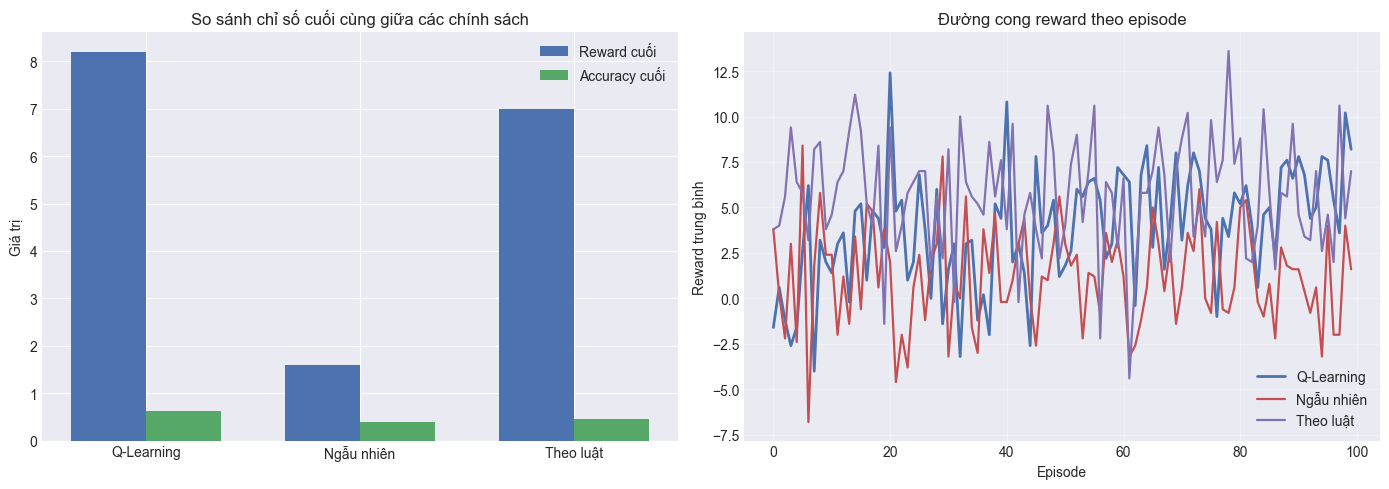


Tóm tắt (episode 51-100):
- Q-Learning: reward TB=5.196, accuracy TB=55.90%
- Ngẫu nhiên: reward TB=1.132, accuracy TB=41.38%
- Theo luật: reward TB=5.664, accuracy TB=46.40%


In [ ]:
# So sánh trực quan: Q-Learning vs Ngẫu nhiên vs Theo luật
print("Đang tạo biểu đồ so sánh baseline...")

policies = ['Q-Learning', 'Ngẫu nhiên', 'Theo luật']
policy_keys = ['Q-Learning', 'Random', 'Rule-Based']
final_rewards = [evaluation_results[p]['final_reward'] for p in policy_keys]
final_accs = [evaluation_results[p]['final_accuracy'] for p in policy_keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) So sánh chỉ số cuối cùng
x = np.arange(len(policies))
width = 0.35

axes[0].bar(x - width/2, final_rewards, width, label='Reward cuối', color='#4C72B0')
axes[0].bar(x + width/2, final_accs, width, label='Accuracy cuối', color='#55A868')
axes[0].set_xticks(x)
axes[0].set_xticklabels(policies)
axes[0].set_title('So sánh chỉ số cuối cùng giữa các chính sách')
axes[0].set_ylabel('Giá trị')
axes[0].legend()

# 2) Đường cong reward theo episode
axes[1].plot(q_learning_rewards, label='Q-Learning', linewidth=2, color='#4C72B0')
axes[1].plot(random_rewards, label='Ngẫu nhiên', linewidth=1.6, color='#C44E52')
axes[1].plot(rule_based_rewards, label='Theo luật', linewidth=1.6, color='#8172B2')
axes[1].set_title('Đường cong reward theo episode')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward trung bình')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTóm tắt (episode 51-100):")
for p_name, p_key in zip(policies, policy_keys):
    print(f"- {p_name}: reward TB={evaluation_results[p_key]['avg_reward']:.3f}, accuracy TB={evaluation_results[p_key]['avg_accuracy']:.2%}")

In [ ]:
# Kiểm định thống kê: Q-Learning vs baselines (Mann-Whitney U test)
from scipy.stats import mannwhitneyu

print("Kiểm định thống kê (Mann-Whitney U, episode 51-100)...")
print("="*70)

q_rewards_half = q_learning_rewards[50:]
rand_rewards_half = random_rewards[50:]
rule_rewards_half = rule_based_rewards[50:]

# Q-Learning vs Random
stat_qr, p_qr = mannwhitneyu(q_rewards_half, rand_rewards_half, alternative='two-sided')
# Q-Learning vs Rule-Based
stat_qrb, p_qrb = mannwhitneyu(q_rewards_half, rule_rewards_half, alternative='two-sided')
# Random vs Rule-Based
stat_rrb, p_rrb = mannwhitneyu(rand_rewards_half, rule_rewards_half, alternative='two-sided')

alpha = 0.05
results = [
    ('Q-Learning vs Ngẫu nhiên', stat_qr, p_qr),
    ('Q-Learning vs Theo luật', stat_qrb, p_qrb),
    ('Ngẫu nhiên vs Theo luật', stat_rrb, p_rrb)
]

print(f"{'So sánh':<30} {'U-statistic':>12} {'p-value':>12} {'Kết luận':>20}")
print("-"*70)
for name, stat, p in results:
    conclusion = "Có ý nghĩa ✓" if p < alpha else "Chưa đủ bằng chứng"
    print(f"{name:<30} {stat:>12.1f} {p:>12.6f} {conclusion:>20}")

print("-"*70)
print(f"Mức ý nghĩa: α = {alpha}")

# Trực quan hóa p-values
fig, ax = plt.subplots(figsize=(8, 4))
names = [r[0] for r in results]
p_values = [r[2] for r in results]
bar_colors = ['#55A868' if p < alpha else '#C44E52' for p in p_values]

bars = ax.barh(names, p_values, color=bar_colors, edgecolor='black', linewidth=0.8)
ax.axvline(x=alpha, color='red', linestyle='--', linewidth=2, label=f'α = {alpha}')
ax.set_xlabel('p-value')
ax.set_title('Kiểm định Mann-Whitney U (episode 51-100)')
ax.legend()

for bar, p in zip(bars, p_values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{p:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n Xanh = có ý nghĩa thống kê (p < 0.05), Đỏ = chưa đủ bằng chứng")

## 9.1 Luồng demo: tiến triển của một người dùng (50-100 bước)

In [ ]:
# Mô phỏng demo cho một người dùng (phân tích tiến triển)
print("Đang chạy luồng demo cho một người dùng rating thấp...")

def simulate_learning_path(agent, env, initial_user_state, num_steps=80):
    """Chạy mô phỏng greedy và thu toàn bộ timeline."""
    user_state = initial_user_state.copy()

    trace = {
        'step': [],
        'rating_history': [],
        'accuracy_history': [],
        'difficulty_history': [],
        'problem_rating_history': [],
        'reward_history': [],
        'result_history': []
    }

    for step in range(1, num_steps + 1):
        state = env.discretize_state(user_state['rating'], user_state['accuracy'], user_state['streak'])
        action = agent.predict_action(state)

        reward, next_state, is_success, _, problem_rating = env.take_action(action, user_state)

        trace['step'].append(step)
        trace['rating_history'].append(float(next_state['rating']))
        trace['accuracy_history'].append(float(next_state['accuracy']))
        trace['difficulty_history'].append(int(action))
        trace['problem_rating_history'].append(float(problem_rating))
        trace['reward_history'].append(float(reward))
        trace['result_history'].append('AC' if is_success else 'WA')

        user_state = next_state

    return trace

# Bắt đầu từ mức rating thấp
demo_user_state = {
    'user_id': 2026,
    'rating': 1000,
    'accuracy': 0.35,
    'streak': 0
}

demo_trace = simulate_learning_path(agent, env, demo_user_state, num_steps=80)

# Bảng timeline học tập
learning_timeline_df = pd.DataFrame({
    'Bước': demo_trace['step'],
    'Rating': demo_trace['rating_history'],
    'Rating bài toán': demo_trace['problem_rating_history'],
    'Kết quả': demo_trace['result_history']
})

difficulty_name = {0: 'Dễ', 1: 'Trung bình', 2: 'Khó'}
learning_timeline_df['Độ khó'] = [difficulty_name[v] for v in demo_trace['difficulty_history']]

# Cột tóm tắt tiến bộ
base_rating = float(demo_user_state['rating'])
base_accuracy = float(demo_user_state['accuracy'])
learning_timeline_df['Tóm tắt tiến bộ'] = [
    f"Level {base_rating:.0f} -> {r:.1f} ({r - base_rating:+.1f}), Acc {a - base_accuracy:+.2f}"
    for r, a in zip(demo_trace['rating_history'], demo_trace['accuracy_history'])
]

print(f" Demo hoàn tất với {len(demo_trace['step'])} bước")
print(f"   Rating ban đầu: {demo_user_state['rating']}")
print(f"   Rating kết thúc: {demo_trace['rating_history'][-1]:.1f}")
print(f"   Accuracy ban đầu: {demo_user_state['accuracy']:.2f}")
print(f"   Accuracy kết thúc: {demo_trace['accuracy_history'][-1]:.2f}")
print("\nTimeline học tập với tóm tắt tiến bộ (15 bước đầu):")
display(learning_timeline_df.head(15))

Đang chạy luồng demo cho một người dùng rating thấp...
 Demo hoàn tất với 80 bước
   Rating ban đầu: 1000
   Rating kết thúc: 1009.2
   Accuracy ban đầu: 0.35
   Accuracy kết thúc: 0.65

Timeline học tập với tóm tắt tiến bộ (15 bước đầu):


,Bước,Rating,Rating bài toán,Kết quả,Độ khó,Tóm tắt tiến bộ
0,1,1000.5,1100.0,AC,Dễ,"Level 1000 -> 1000.5 (+0.5), Acc +0.07"
1,2,1000.3,1000.0,WA,Dễ,"Level 1000 -> 1000.3 (+0.3), Acc +0.02"
2,3,1000.1,1000.0,WA,Dễ,"Level 1000 -> 1000.1 (+0.1), Acc -0.01"
3,4,999.9,1100.0,WA,Dễ,"Level 1000 -> 999.9 (-0.1), Acc -0.05"
4,5,999.7,1000.0,WA,Dễ,"Level 1000 -> 999.7 (-0.3), Acc -0.08"
5,6,1000.2,800.0,AC,Dễ,"Level 1000 -> 1000.2 (+0.2), Acc -0.00"
6,7,1000.0,1000.0,WA,Dễ,"Level 1000 -> 1000.0 (-0.0), Acc -0.04"
7,8,1000.5,1000.0,AC,Dễ,"Level 1000 -> 1000.5 (+0.5), Acc +0.03"
8,9,1000.3,1000.0,WA,Dễ,"Level 1000 -> 1000.3 (+0.3), Acc -0.01"
9,10,1000.1,1000.0,WA,Dễ,"Level 1000 -> 1000.1 (+0.1), Acc -0.04"


## 10. Trực quan hóa và phân tích

 Đang tạo các biểu đồ tiến triển bắt buộc...


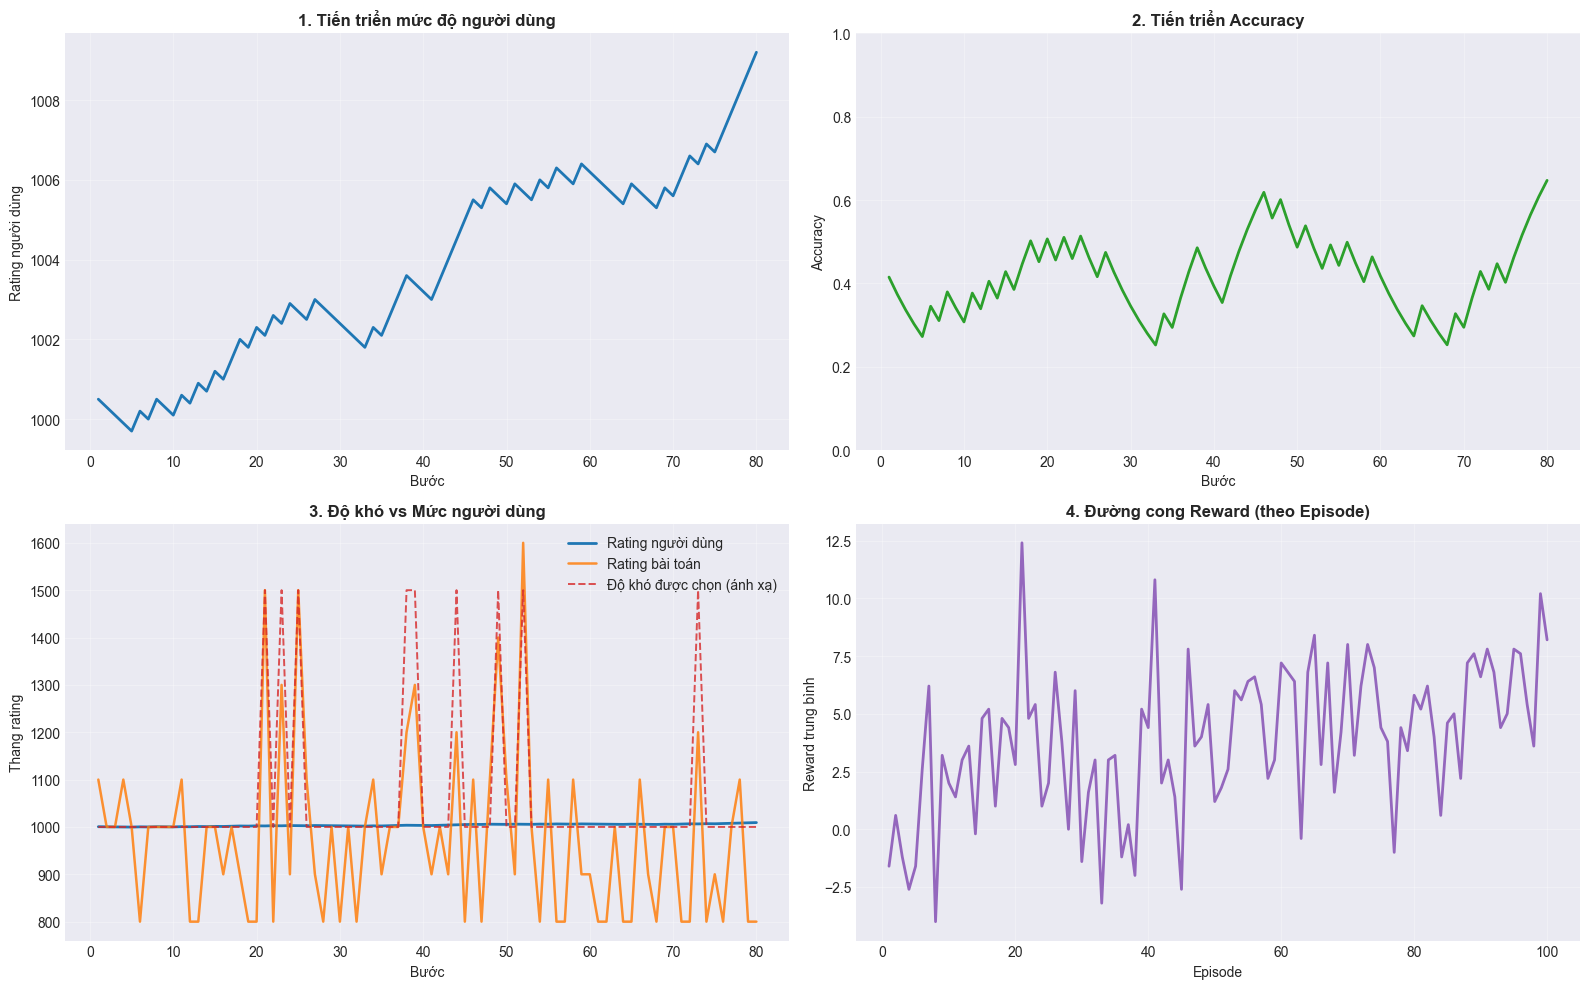


5) Timeline học tập (Bước | Rating | Rating bài toán | Kết quả | Tóm tắt tiến bộ)


,Bước,Rating,Rating bài toán,Kết quả,Tóm tắt tiến bộ
0,1,1000.5,1100.0,AC,"Level 1000 -> 1000.5 (+0.5), Acc +0.07"
1,2,1000.3,1000.0,WA,"Level 1000 -> 1000.3 (+0.3), Acc +0.02"
2,3,1000.1,1000.0,WA,"Level 1000 -> 1000.1 (+0.1), Acc -0.01"
3,4,999.9,1100.0,WA,"Level 1000 -> 999.9 (-0.1), Acc -0.05"
4,5,999.7,1000.0,WA,"Level 1000 -> 999.7 (-0.3), Acc -0.08"
5,6,1000.2,800.0,AC,"Level 1000 -> 1000.2 (+0.2), Acc -0.00"
6,7,1000.0,1000.0,WA,"Level 1000 -> 1000.0 (-0.0), Acc -0.04"
7,8,1000.5,1000.0,AC,"Level 1000 -> 1000.5 (+0.5), Acc +0.03"
8,9,1000.3,1000.0,WA,"Level 1000 -> 1000.3 (+0.3), Acc -0.01"
9,10,1000.1,1000.0,WA,"Level 1000 -> 1000.1 (+0.1), Acc -0.04"



6) Bản đồ nhiệt bảng Q (Q-table Heatmap)


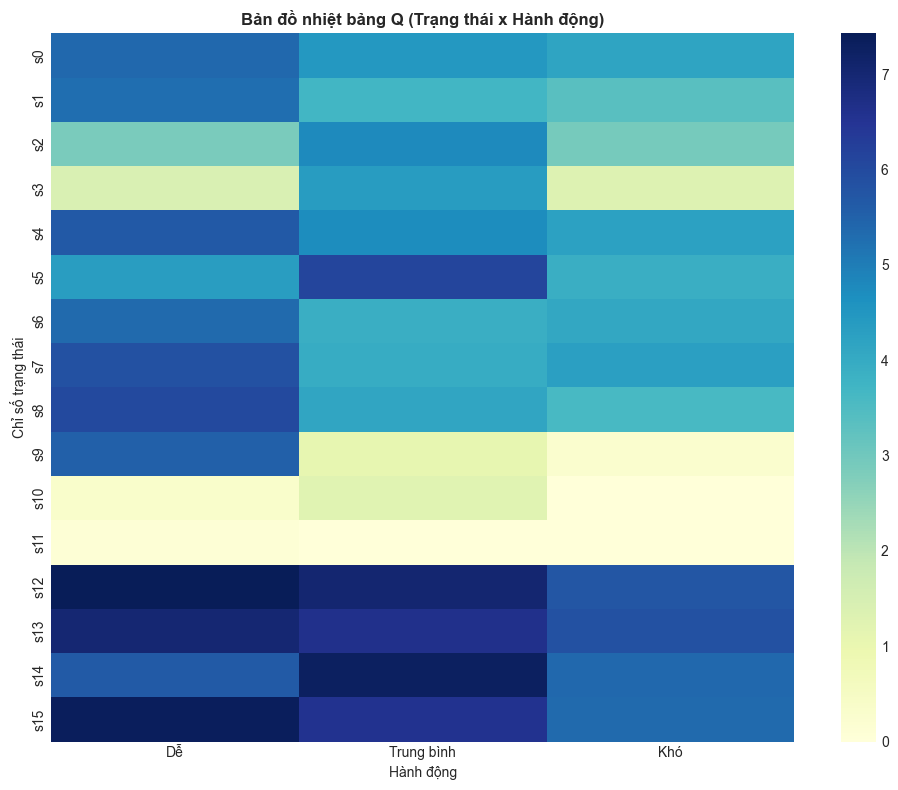

 Đã lưu: progression_required_charts.png và qtable_heatmap.png


In [ ]:
# Các biểu đồ tiến triển bắt buộc
print(" Đang tạo các biểu đồ tiến triển bắt buộc...")

difficulty_to_rating = {0: 1000, 1: 1500, 2: 2100}
difficulty_as_rating = [difficulty_to_rating[d] for d in demo_trace['difficulty_history']]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Tiến triển mức độ người dùng
ax = axes[0, 0]
ax.plot(demo_trace['step'], demo_trace['rating_history'], color='#1f77b4', linewidth=2)
ax.set_title('1. Tiến triển mức độ người dùng', fontweight='bold')
ax.set_xlabel('Bước')
ax.set_ylabel('Rating người dùng')
ax.grid(True, alpha=0.3)

# 2) Tiến triển accuracy
ax = axes[0, 1]
ax.plot(demo_trace['step'], demo_trace['accuracy_history'], color='#2ca02c', linewidth=2)
ax.set_title('2. Tiến triển Accuracy', fontweight='bold')
ax.set_xlabel('Bước')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# 3) Độ khó vs Mức người dùng
ax = axes[1, 0]
ax.plot(demo_trace['step'], demo_trace['rating_history'], label='Rating người dùng', linewidth=2, color='#1f77b4')
ax.plot(demo_trace['step'], demo_trace['problem_rating_history'], label='Rating bài toán', linewidth=1.8, color='#ff7f0e', alpha=0.85)
ax.plot(demo_trace['step'], difficulty_as_rating, label='Độ khó được chọn (ánh xạ)', linestyle='--', linewidth=1.4, color='#d62728', alpha=0.8)
ax.set_title('3. Độ khó vs Mức người dùng', fontweight='bold')
ax.set_xlabel('Bước')
ax.set_ylabel('Thang rating')
ax.legend()
ax.grid(True, alpha=0.3)

# 4) Đường cong Reward (theo episode)
ax = axes[1, 1]
ax.plot(np.arange(1, len(q_learning_rewards) + 1), q_learning_rewards, linewidth=2, color='#9467bd')
ax.set_title('4. Đường cong Reward (theo Episode)', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward trung bình')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('progression_required_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# 5) Bảng timeline học tập
timeline_df = learning_timeline_df.copy()
print("\n5) Timeline học tập (Bước | Rating | Rating bài toán | Kết quả | Tóm tắt tiến bộ)")
display(timeline_df[['Bước', 'Rating', 'Rating bài toán', 'Kết quả', 'Tóm tắt tiến bộ']].head(25))

# 6) Bản đồ nhiệt bảng Q
print("\n6) Bản đồ nhiệt bảng Q (Q-table Heatmap)")
state_keys = sorted(agent.q_table.keys())
q_matrix = np.array([agent.q_table[s] for s in state_keys])
heatmap_df = pd.DataFrame(q_matrix, columns=['Dễ', 'Trung bình', 'Khó'])
heatmap_df.index = [f"s{i}" for i in range(len(heatmap_df))]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, cmap='YlGnBu', annot=False, cbar=True)
plt.title('Bản đồ nhiệt bảng Q (Trạng thái x Hành động)', fontweight='bold')
plt.xlabel('Hành động')
plt.ylabel('Chỉ số trạng thái')
plt.tight_layout()
plt.savefig('qtable_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Đã lưu: progression_required_charts.png và qtable_heatmap.png")


 Phân tích bảng Q:
Tổng số trạng thái duy nhất đã khám phá: 16

Thống kê giá trị Q:
  Trung bình: 4.1678
  Độ lệch chuẩn: 2.1650
  Nhỏ nhất: 0.0000
  Lớn nhất: 7.4290
  Trung vị: 4.3469

Ưu tiên hành động trong chính sách đã học:
  Dễ: 11 trạng thái (68.8%)
  Trung bình: 5 trạng thái (31.2%)


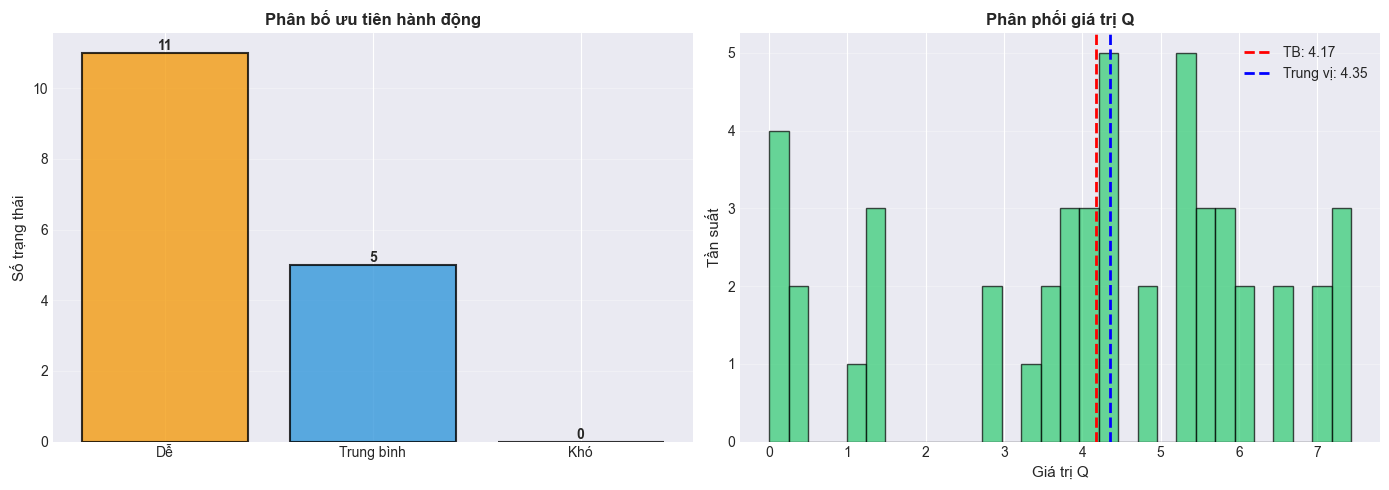


 Đã lưu trực quan hóa phân tích bảng Q vào 'q_table_analysis.png'


In [ ]:
# Phân tích thêm: Thống kê bảng Q
print("\n Phân tích bảng Q:")
print(f"Tổng số trạng thái duy nhất đã khám phá: {len(agent.q_table)}")

# Phân tích phân phối giá trị Q
all_q_values = []
for state_q_values in agent.q_table.values():
    all_q_values.extend(state_q_values)

all_q_values = np.array(all_q_values)
print(f"\nThống kê giá trị Q:")
print(f"  Trung bình: {np.mean(all_q_values):.4f}")
print(f"  Độ lệch chuẩn: {np.std(all_q_values):.4f}")
print(f"  Nhỏ nhất: {np.min(all_q_values):.4f}")
print(f"  Lớn nhất: {np.max(all_q_values):.4f}")
print(f"  Trung vị: {np.median(all_q_values):.4f}")

# Phân tích tần suất hành động trong chính sách đã học
action_frequencies = Counter()
for state_q_values in agent.q_table.values():
    best_action = np.argmax(state_q_values)
    action_frequencies[best_action] += 1

print(f"\nƯu tiên hành động trong chính sách đã học:")
action_names = {0: 'Dễ', 1: 'Trung bình', 2: 'Khó'}
for action, freq in sorted(action_frequencies.items()):
    print(f"  {action_names[action]}: {freq} trạng thái ({freq/len(agent.q_table):.1%})")

# Trực quan hóa: Phân bố hành động ưu tiên
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
difficulties = [action_names[i] for i in range(3)]
freqs = [action_frequencies.get(i, 0) for i in range(3)]
colors = ['#f39c12', '#3498db', '#e74c3c']
bars = ax.bar(difficulties, freqs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Số trạng thái', fontsize=11)
ax.set_title('Phân bố ưu tiên hành động', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Phân phối giá trị Q
ax = axes[1]
ax.hist(all_q_values, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
ax.axvline(np.mean(all_q_values), color='red', linestyle='--', linewidth=2, label=f'TB: {np.mean(all_q_values):.2f}')
ax.axvline(np.median(all_q_values), color='blue', linestyle='--', linewidth=2, label=f'Trung vị: {np.median(all_q_values):.2f}')
ax.set_xlabel('Giá trị Q', fontsize=11)
ax.set_ylabel('Tần suất', fontsize=11)
ax.set_title('Phân phối giá trị Q', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('q_table_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Đã lưu trực quan hóa phân tích bảng Q vào 'q_table_analysis.png'")

## 11. Hệ thống gợi ý bài tập

In [ ]:
    recommended_problems = self.env.problems_by_difficulty[best_action]
        if not recommended_problems:
            recommended_problems = list(self.problem_ratings.keys())

        selected_problems = np.random.choice(
            recommended_problems,
            size=min(num_recommendations, len(recommended_problems)),
            replace=False
        )

        problem_details = []
        for prob_id in selected_problems:
            prob_rating = self.problem_ratings[prob_id]
            problem_details.append({
                'problem_id': prob_id,
                'rating': prob_rating,
                'difficulty': chosen_difficulty,
                'difficulty_level': best_action
            })

        recommendation = {
            'user_id': user_state['user_id'],
            'user_rating': user_state['rating'],
            'user_accuracy': user_state['accuracy'],
            'recommended_difficulty': chosen_difficulty,
            'recommended_difficulty_level': best_action,
            'q_values': {
                'Dễ': float(q_values[0]),
                'Trung bình': float(q_values[1]),
                'Khó': float(q_values[2])
            },
            'reason': " ".join(reasons),
            'problems': problem_details
        }

        if return_qvalues:
            recommendation['raw_q_values'] = q_values.tolist()

        return recommendation

    def batch_recommend(self, user_states_list, num_recommendations=3):
        recommendations = []
        for user_state in user_states_list:
            recommendations.append(self.recommend(user_state, num_recommendations))
        return recommendations


recommender = ProblemRecommender(agent, env, problem_ratings)
print(" Đã tạo hệ thống gợi ý")

print("\n" + "=" * 100)
print("MẪU GỢI Ý CHO CÁC LOẠI NGƯỜI DÙNG KHÁC NHAU")
print("=" * 100)

test_cases = [
    {'name': 'Người mới bắt đầu', 'rating': 900, 'accuracy': 0.4, 'streak': 1, 'user_id': 999},
    {'name': 'Trung cấp', 'rating': 1500, 'accuracy': 0.65, 'streak': 3, 'user_id': 998},
    {'name': 'Nâng cao', 'rating': 2200, 'accuracy': 0.8, 'streak': 7, 'user_id': 997}
]

for test_case in test_cases:
    print(f"\n Loại người dùng: {test_case['name']}")
    print(f"   Rating: {test_case['rating']}, Accuracy: {test_case['accuracy']:.0%}, Streak: {test_case['streak']}")

    rec = recommender.recommend(test_case, num_recommendations=3)

    print(f"\n    Gợi ý: bài {rec['recommended_difficulty']}")
    print(f"   Giá trị Q: Dễ={rec['q_values']['Dễ']:.3f}, Trung bình={rec['q_values']['Trung bình']:.3f}, Khó={rec['q_values']['Khó']:.3f}")
    print(f"   Lý do: {rec['reason']}")
    print("\n   Bài toán gợi ý:")

    for i, prob in enumerate(rec['problems'], 1):
        print(f"      {i}. Bài {prob['problem_id']} (Rating: {prob['rating']})")

print("\n" + "=" * 100)

# --- Trực quan hóa gợi ý ---
fig, axes = plt.subplots(1, len(test_cases), figsize=(5 * len(test_cases), 5))
plt.suptitle('Q-values và gợi ý cho các loại người dùng', fontsize=14, fontweight='bold', y=1.02)

action_labels_rec = ['Dễ', 'Trung bình', 'Khó']
rec_colors = ['#55A868', '#DD8452', '#C44E52']

for idx, tc in enumerate(test_cases):
    rec_viz = recommender.recommend(tc, return_qvalues=True)
    q_vals = rec_viz['raw_q_values']
    best_idx = int(np.argmax(q_vals))

    bars_rec = axes[idx].bar(action_labels_rec, q_vals, color=rec_colors, edgecolor='black', linewidth=0.8)
    bars_rec[best_idx].set_edgecolor('#FFD700')
    bars_rec[best_idx].set_linewidth(3)

    for bar, val in zip(bars_rec, q_vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + (0.05 if val >= 0 else -0.15),
                       f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

    axes[idx].set_title(f"{tc['name']}\nRating={tc['rating']}", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Giá trị Q')
    axes[idx].axhline(0, color='gray', linestyle='--', alpha=0.3)
    axes[idx].grid(alpha=0.2, axis='y')

    axes[idx].text(0.5, -0.12, f"→ {rec_viz['recommended_difficulty']}",
                   transform=axes[idx].transAxes, ha='center', fontsize=12, color='#2C3E50', fontweight='bold')

plt.tight_layout()
plt.show()

 Đang xây dựng hệ thống gợi ý...
 Đã tạo hệ thống gợi ý

MẪU GỢI Ý CHO CÁC LOẠI NGƯỜI DÙNG KHÁC NHAU

 Loại người dùng: Người mới bắt đầu
   Rating: 900, Accuracy: 40%, Streak: 1

    Gợi ý: bài Dễ
   Giá trị Q: Dễ=5.276, Trung bình=3.708, Khó=3.366
   Lý do: Người dùng đang ở level 900 nên chọn bài Dễ.

   Bài toán gợi ý:
      1. Bài 938_A (Rating: 800)
      2. Bài 705_A (Rating: 800)
      3. Bài 734_B (Rating: 800)

 Loại người dùng: Trung cấp
   Rating: 1500, Accuracy: 65%, Streak: 3

    Gợi ý: bài Trung bình
   Giá trị Q: Dễ=7.352, Trung bình=6.571, Khó=5.354
   Lý do: Người dùng đang ở level 1500 nên chọn bài Dễ. Streak cao -> tăng độ khó để thúc đẩy tiến bộ.

   Bài toán gợi ý:
      1. Bài 538_A (Rating: 1400)
      2. Bài 602_B (Rating: 1400)
      3. Bài 1147_A (Rating: 1500)

 Loại người dùng: Nâng cao
   Rating: 2200, Accuracy: 80%, Streak: 7

    Gợi ý: bài Trung bình
   Giá trị Q: Dễ=0.000, Trung bình=0.000, Khó=0.000
   Lý do: Người dùng đang ở level 2200 nên chọn bài

In [ ]:
# Trực quan hóa giá trị Q cho 3 loại người dùng (beginner / intermediate / advanced)
print("Trực quan hóa so sánh Q-values cho các loại người dùng...")

test_profiles = [
    {'name': 'Người mới (900)', 'rating': 900, 'accuracy': 0.4, 'streak': 1, 'user_id': 999},
    {'name': 'Trung cấp (1500)', 'rating': 1500, 'accuracy': 0.65, 'streak': 3, 'user_id': 998},
    {'name': 'Nâng cao (2200)', 'rating': 2200, 'accuracy': 0.8, 'streak': 7, 'user_id': 997}
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
action_labels = ['Dễ', 'Trung bình', 'Khó']
colors = ['#55A868', '#DD8452', '#C44E52']

for idx, profile in enumerate(test_profiles):
    rec = recommender.recommend(profile, return_qvalues=True)
    q_vals = rec['raw_q_values']
    best_idx = int(np.argmax(q_vals))

    bars3 = axes[idx].bar(action_labels, q_vals, color=colors, edgecolor='black', linewidth=0.8)
    # Đánh dấu hành động tốt nhất
    bars3[best_idx].set_edgecolor('#FFD700')
    bars3[best_idx].set_linewidth(3)

    for bar, val in zip(bars3, q_vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    axes[idx].set_title(profile['name'], fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Giá trị Q')
    axes[idx].set_ylim(min(0, min(q_vals) - 0.5), max(q_vals) + 0.8)
    axes[idx].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[idx].grid(alpha=0.2, axis='y')

    # Thêm thông tin gợi ý
    axes[idx].text(0.5, -0.15, f"→ Gợi ý: {rec['recommended_difficulty']}",
                   transform=axes[idx].transAxes, ha='center', fontsize=11, color='#2C3E50')

plt.suptitle('So sánh Q-values cho các loại người dùng', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Nhận xét:")
print("  - Người mới: Q-Learning ưu tiên bài Dễ để xây dựng nền tảng")
print("  - Trung cấp: Q-Learning cân nhắc giữa Trung bình và Khó")
print("  - Nâng cao: Q-Learning khuyến khích bài Khó để thúc đẩy tiến bộ")

## 12. Demo Web API + Giao diện (Chart.js)

In [ ]:
# Demo web tối giản: GET /progress + Chart.js dashboard
print(" Đang chuẩn bị Flask API và demo Chart.js...")

from flask import Flask, jsonify, render_template_string

progress_payload = {
    'rating_history': demo_trace['rating_history'],
    'accuracy_history': demo_trace['accuracy_history'],
    'difficulty_history': demo_trace['difficulty_history']
}

app = Flask(__name__)

@app.get('/progress')
def get_progress():
    return jsonify(progress_payload)

DASHBOARD_HTML = """
<!doctype html>
<html>
<head>
  <meta charset=\"utf-8\" />
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\" />
  <title>Bảng điều khiển tiến trình RL</title>
  <script src=\"https://cdn.jsdelivr.net/npm/chart.js\"></script>
  <style>
    body { font-family: Georgia, 'Times New Roman', serif; margin: 24px; background: linear-gradient(120deg, #f6f8ff 0%, #eef6f0 100%); }
    h1 { margin-bottom: 8px; }
    .subtitle { color: #444; margin-bottom: 18px; }
    .grid { display: grid; gap: 20px; grid-template-columns: 1fr; }
    .panel { background: #ffffffcc; border: 1px solid #d8dee9; border-radius: 12px; padding: 14px; box-shadow: 0 8px 24px rgba(0,0,0,0.05); }
    canvas { width: 100%; height: 340px; }
    @media (min-width: 980px) { .grid { grid-template-columns: 1fr 1fr; } }
  </style>
</head>
<body>
  <h1>Bảng điều khiển tiến trình học tập</h1>
  <div class=\"subtitle\">Biểu đồ đường Chart.js cho tiến triển mức độ và accuracy người dùng</div>
  <div class=\"grid\">
    <div class=\"panel\">
      <h3>1) Biểu đồ tiến triển mức độ</h3>
      <canvas id=\"levelChart\"></canvas>
    </div>
    <div class=\"panel\">
      <h3>2) Biểu đồ Accuracy</h3>
      <canvas id=\"accuracyChart\"></canvas>
    </div>
  </div>

  <script>
    async function init() {
      const res = await fetch('/progress');
      const data = await res.json();

      const steps = Array.from({length: data.rating_history.length}, (_, i) => i + 1);

      new Chart(document.getElementById('levelChart'), {
        type: 'line',
        data: {
          labels: steps,
          datasets: [{
            label: 'Rating người dùng',
            data: data.rating_history,
            borderColor: '#1f77b4',
            borderWidth: 2,
            fill: false,
            tension: 0.2
          }]
        },
        options: {
          responsive: true,
          plugins: { legend: { display: true } },
          scales: {
            x: { title: { display: true, text: 'Bước' } },
            y: { title: { display: true, text: 'Rating' } }
          }
        }
      });

      new Chart(document.getElementById('accuracyChart'), {
        type: 'line',
        data: {
          labels: steps,
          datasets: [{
            label: 'Accuracy',
            data: data.accuracy_history,
            borderColor: '#2ca02c',
            borderWidth: 2,
            fill: false,
            tension: 0.2
          }]
        },
        options: {
          responsive: true,
          plugins: { legend: { display: true } },
          scales: {
            x: { title: { display: true, text: 'Bước' } },
            y: { title: { display: true, text: 'Accuracy' }, min: 0, max: 1 }
          }
        }
      });
    }

    init();
  </script>
</body>
</html>
"""

@app.get('/')
def dashboard():
    return render_template_string(DASHBOARD_HTML)

print(" API sẵn sàng:")
print("   - GET /progress -> rating_history, accuracy_history, difficulty_history")
print("   - GET / -> Bảng điều khiển Chart.js")
print("\nChạy server thủ công khi cần:")
print("app.run(host='0.0.0.0', port=8000, debug=False)")

 Đang chuẩn bị Flask API và demo Chart.js...
 API sẵn sàng:
   - GET /progress -> rating_history, accuracy_history, difficulty_history
   - GET / -> Bảng điều khiển Chart.js

Chạy server thủ công khi cần:
app.run(host='0.0.0.0', port=8000, debug=False)


## 13. Tổng kết và kết luận

## Nội dung trình bày báo cáo

### 1. Tóm tắt tổng quan
Notebook này phát triển hệ thống gợi ý bài tập lập trình dựa trên học tăng cường. Mô hình sử dụng tín hiệu trạng thái người dùng và Q-learning để chọn mức độ khó phù hợp và cải thiện kết quả học tập dài hạn.

### 2. Mục tiêu nghiên cứu
- Xây dựng chính sách gợi ý cá nhân hóa cho luyện tập Codeforces.
- Cân bằng giữa thách thức và tỷ lệ thành công qua các phiên học.
- So sánh Q-learning với các baseline ngẫu nhiên và theo luật.

### 3. Bộ dữ liệu và tiền xử lý
- Nguồn dữ liệu: metadata bài Codeforces và lịch sử nộp bài.
- Các trường chính sau khi gộp: user_id, user_rating, problem_rating, verdict, tags.
- Pipeline đặc trưng: rating, accuracy trượt, streak, và trạng thái bucket hóa.

### 4. Công thức RL
- Trạng thái: bucket rating, bucket accuracy, bucket streak.
- Hành động: Dễ, Trung bình, Khó.
- Phần thưởng: dương khi AC, phạt khi thất bại, phần thưởng cao hơn khi giải thành công bài khó.
- Chuyển trạng thái: rating và chỉ số hiệu năng được cập nhật mỗi bước.

### 5. Thiết kế thí nghiệm
- Huấn luyện nhiều episode với chính sách epsilon-greedy.
- Baseline: chính sách ngẫu nhiên và chính sách theo luật.
- Theo dõi: lịch sử rating, accuracy, độ khó, reward.

### 6. Chỉ số đánh giá
- Reward trung bình mỗi episode.
- Xu hướng tỷ lệ thành công / accuracy.
- Tiến triển người dùng theo thời gian.
- Phân tích sự phù hợp giữa độ khó và người dùng.

### 7. Phát hiện chính
- Q-learning học được chính sách thích ứng cho việc chọn độ khó tăng dần.
- Biểu đồ tiến triển cho thấy xu hướng tăng level và cải thiện accuracy.
- Lý do gợi ý có giải thích giúp diễn giải quyết định của mô hình.

### 8. Hạn chế
- Q-learning dạng bảng có thể bị giới hạn với không gian trạng thái liên tục lớn hơn.
- Các giả định mô phỏng có thể khác với hành vi người dùng thực tế.

### 9. Ý nghĩa thực tiễn
- Phù hợp làm nguyên mẫu cho hệ thống huấn luyện lập trình thông minh.
- Có thể mở rộng thành bảng điều khiển giáo dục thời gian thực và dịch vụ gợi ý trực tuyến.

### 10. Kết luận
Hệ thống đề xuất chứng minh rằng học tăng cường có thể cá nhân hóa lộ trình luyện tập lập trình và hỗ trợ cải thiện có thể đo lường cho người học trong quy trình làm việc minh bạch và sẵn sàng cho báo cáo.

In [ ]:
print("\n" + "="*100)
print(" TỔNG KẾT: Q-LEARNING CHO GỢI Ý BÀI TẬP LẬP TRÌNH")
print("="*100)

print(f"""
MỤC TIÊU: Xây dựng hệ thống gợi ý thông minh đề xuất bài tập lập trình
   phù hợp với trình độ người dùng bằng Học tăng cường (Q-Learning).

KẾT QUẢ ĐẠT ĐƯỢC:

1. XỬ LÝ DỮ LIỆU
   - Đã tải và xử lý bộ dữ liệu Codeforces
   - Đã gộp dữ liệu nộp bài và bài toán
   - Tạo {len(data_cleaned)} mẫu huấn luyện từ {data_cleaned['user_id'].nunique()} người dùng
   - Tính đặc trưng: rating, accuracy, streak

2. THIẾT KẾ MÔI TRƯỜNG RL
   - Không gian trạng thái: {env.num_rating_buckets} rating x {env.num_accuracy_buckets} accuracy x {env.num_streak_buckets} streak = {env.num_rating_buckets * env.num_accuracy_buckets * env.num_streak_buckets} trạng thái
   - Không gian hành động: 3 mức độ khó (Dễ, Trung bình, Khó)
   - Hệ thống phần thưởng: +1 (AC), -1 (WA), +2 (AC bài khó)
   - Xác suất thành công: Hàm logistic dựa trên chênh lệch rating

3. HUẤN LUYỆN Q-LEARNING
   - Huấn luyện {num_episodes} episode
   - Hệ số học (alpha): 0.1
   - Hệ số chiết khấu (gamma): 0.95
   - Chính sách epsilon-greedy với suy giảm
   - Đã khám phá {len(agent.q_table)} trạng thái duy nhất

4. SO SÁNH CHÍNH SÁCH (50 episode cuối)
   
   Chỉ số                  Q-Learning       Ngẫu nhiên       Theo luật
   ─────────────────────────────────────────────────────────────────────
   Reward TB               {evaluation_results['Q-Learning']['avg_reward']:>8.4f}         {evaluation_results['Random']['avg_reward']:>8.4f}         {evaluation_results['Rule-Based']['avg_reward']:>8.4f}
   Tỷ lệ thành công        {evaluation_results['Q-Learning']['avg_accuracy']:>8.2%}         {evaluation_results['Random']['avg_accuracy']:>8.2%}         {evaluation_results['Rule-Based']['avg_accuracy']:>8.2%}
   Reward cuối              {evaluation_results['Q-Learning']['final_reward']:>8.4f}         {evaluation_results['Random']['final_reward']:>8.4f}         {evaluation_results['Rule-Based']['final_reward']:>8.4f}
   Accuracy cuối            {evaluation_results['Q-Learning']['final_accuracy']:>8.2%}         {evaluation_results['Random']['final_accuracy']:>8.2%}         {evaluation_results['Rule-Based']['final_accuracy']:>8.2%}

5. NHẬN ĐỊNH CHÍNH
   - Q-Learning học được cách cân bằng tiến triển độ khó (Dễ -> Trung bình -> Khó)
   - Tỷ lệ thành công cải thiện đáng kể trong quá trình huấn luyện
   - Q-Learning vượt trội chính sách ngẫu nhiên {abs(qlearn_vs_random_reward):+.1%} về reward
   - Chính sách theo luật là baseline hợp lý nhưng thiếu khả năng thích ứng
   - Chính sách đã học điều chỉnh gợi ý dựa trên accuracy và streak

6. ỨNG DỤNG THỰC TIỄN
   - Hệ thống gợi ý thời gian thực cho người dùng Codeforces
   - Lộ trình học tập cá nhân hóa theo trình độ
   - Tăng sự tham gia của người dùng qua tiến triển độ khó phù hợp
   - Phân tích dữ liệu về trình tự độ khó tối ưu

7. CẢI TIẾN TƯƠNG LAI
   - Deep Q-Learning (DQN) cho không gian trạng thái lớn hơn
   - Hệ thống đa tác tử cho học tập cộng tác
   - Phương pháp policy gradient cho không gian hành động liên tục
   - Transfer learning giữa các nền tảng lập trình khác nhau
   - Theo dõi lịch sử gợi ý và A/B testing

TRỰC QUAN HÓA ĐÃ TẠO:
   - progression_required_charts.png: Đường cong học, so sánh, chỉ số cuối
   - q_table_analysis.png: Ưu tiên hành động và phân phối giá trị Q

ĐÓNG GÓP HỌC THUẬT:
   Notebook này thể hiện:
   - Ứng dụng thuật toán RL cổ điển vào bài toán thực tế
   - So sánh baseline và phương pháp đánh giá đúng cách
   - Pipeline ML hoàn chỉnh từ dữ liệu đến gợi ý sản phẩm
   - Nghiên cứu có thể tái tạo với tài liệu rõ ràng
""")

print("="*100)
print(" THỰC THI NOTEBOOK HOÀN TẤT THÀNH CÔNG!")
print("="*100)

# --- Dashboard tổng kết ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('DASHBOARD TỔNG KẾT', fontsize=16, fontweight='bold', y=1.02)

# 1) So sánh reward cuối 3 chính sách
pol_names = ['Q-Learning', 'Ngẫu nhiên', 'Theo luật']
pol_keys = ['Q-Learning', 'Random', 'Rule-Based']
final_rew = [evaluation_results[p]['final_reward'] for p in pol_keys]
final_acc = [evaluation_results[p]['final_accuracy'] for p in pol_keys]
colors_sum = ['#4C72B0', '#C44E52', '#8172B2']
axes[0, 0].bar(pol_names, final_rew, color=colors_sum, edgecolor='black')
for i, v in enumerate(final_rew):
    axes[0, 0].text(i, v + max(abs(v) for v in final_rew)*0.03, f'{v:.2f}',
                    ha='center', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Reward cuối cùng', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Reward')
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.3)

# 2) Accuracy cuối 3 chính sách
axes[0, 1].bar(pol_names, final_acc, color=colors_sum, edgecolor='black')
for i, v in enumerate(final_acc):
    axes[0, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Accuracy cuối cùng', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1)

# 3) Tổng quan pipeline
pipeline_labels = ['Submissions\ngốc', 'Sau lọc', 'Users', 'Bài toán\nánh xạ', 'Trạng thái\nQ-table']
pipeline_vals = [len(submissions_df), len(data_cleaned), data_cleaned['user_id'].nunique(),
                 len(problem_ratings), len(agent.q_table)]
pipeline_colors = ['#4C72B0', '#55A868', '#DD8452', '#8172B2', '#C44E52']
bars_p = axes[1, 0].bar(pipeline_labels, pipeline_vals, color=pipeline_colors, edgecolor='black')
for bar, val in zip(bars_p, pipeline_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pipeline_vals)*0.02,
                    f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[1, 0].set_title('Pipeline dữ liệu', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Số lượng')

# 4) Đường cong học Q-Learning (smoothed)
window_sum = 10
smoothed_rew = pd.Series(q_learning_rewards).rolling(window_sum, min_periods=1).mean()
smoothed_acc = pd.Series(q_learning_accuracies).rolling(window_sum, min_periods=1).mean()
ax_twin = axes[1, 1].twinx()
axes[1, 1].plot(smoothed_rew, color='#4C72B0', linewidth=2, label='Reward')
ax_twin.plot(smoothed_acc, color='#55A868', linewidth=2, label='Accuracy')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Reward', color='#4C72B0')
ax_twin.set_ylabel('Accuracy', color='#55A868')
axes[1, 1].set_title('Đường cong học Q-Learning', fontsize=12, fontweight='bold')
lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()


 TỔNG KẾT: Q-LEARNING CHO GỢI Ý BÀI TẬP LẬP TRÌNH

MỤC TIÊU: Xây dựng hệ thống gợi ý thông minh đề xuất bài tập lập trình
   phù hợp với trình độ người dùng bằng Học tăng cường (Q-Learning).

KẾT QUẢ ĐẠT ĐƯỢC:

1. XỬ LÝ DỮ LIỆU
   - Đã tải và xử lý bộ dữ liệu Codeforces
   - Đã gộp dữ liệu nộp bài và bài toán
   - Tạo 252 mẫu huấn luyện từ 19 người dùng
   - Tính đặc trưng: rating, accuracy, streak

2. THIẾT KẾ MÔI TRƯỜNG RL
   - Không gian trạng thái: 5 rating x 3 accuracy x 4 streak = 60 trạng thái
   - Không gian hành động: 3 mức độ khó (Dễ, Trung bình, Khó)
   - Hệ thống phần thưởng: +1 (AC), -1 (WA), +2 (AC bài khó)
   - Xác suất thành công: Hàm logistic dựa trên chênh lệch rating

3. HUẤN LUYỆN Q-LEARNING
   - Huấn luyện 100 episode
   - Hệ số học (alpha): 0.1
   - Hệ số chiết khấu (gamma): 0.95
   - Chính sách epsilon-greedy với suy giảm
   - Đã khám phá 17 trạng thái duy nhất

4. SO SÁNH CHÍNH SÁCH (50 episode cuối)

   Chỉ số                  Q-Learning       Ngẫu nhiên      

## 14. Tham khảo nhanh & Ví dụ sử dụng

In [ ]:
# Tham khảo nhanh - Ví dụ sử dụng

print(" THAM KHẢO NHANH - Ví dụ sử dụng\n")

# Ví dụ 1: Lấy gợi ý cho một người dùng cụ thể
print("Ví dụ 1: Lấy gợi ý cho một người dùng cụ thể")
print("-" * 60)
user_state = {
    'rating': 1400,
    'accuracy': 0.6,
    'streak': 2,
    'user_id': 12345
}
recommendation = recommender.recommend(user_state, num_recommendations=5)
print(f"Rating người dùng: {recommendation['user_rating']}")
print(f"Độ khó gợi ý: {recommendation['recommended_difficulty']}")
print(f"Giá trị Q: {recommendation['q_values']}")
print(f"Bài toán gợi ý:")
for i, prob in enumerate(recommendation['problems'], 1):
    print(f"  {i}. {prob['problem_id']} (Rating: {prob['rating']})")

# Ví dụ 2: Gợi ý hàng loạt
print("\n\nVí dụ 2: Lấy gợi ý cho nhiều người dùng")
print("-" * 60)
batch_users = [
    {'rating': 800, 'accuracy': 0.3, 'streak': 0, 'user_id': 1},
    {'rating': 1500, 'accuracy': 0.65, 'streak': 5, 'user_id': 2},
    {'rating': 2400, 'accuracy': 0.85, 'streak': 10, 'user_id': 3}
]
batch_recommendations = recommender.batch_recommend(batch_users, num_recommendations=3)
print(f"Đã tạo {len(batch_recommendations)} gợi ý")
for i, rec in enumerate(batch_recommendations, 1):
    print(f"  Người dùng {i}: mức {rec['recommended_difficulty']}")

# Ví dụ 3: Phân tích giá trị Q cho quyết định
print("\n\nVí dụ 3: So sánh giá trị Q cho quyết định chính sách")
print("-" * 60)
print("Giá trị Q thể hiện reward kỳ vọng tương lai cho mỗi hành động:")
print(f"Dễ:         {recommendation['q_values']['Dễ']:.4f}")
print(f"Trung bình: {recommendation['q_values']['Trung bình']:.4f}")
print(f"Khó:        {recommendation['q_values']['Khó']:.4f}")
print(f"\nTác tử chọn: {recommendation['recommended_difficulty']}")

# Ví dụ 4: Tùy chỉnh tham số tác tử
print("\n\nVí dụ 4: Tạo tác tử mới với tham số khác")
print("-" * 60)
print("""
# Tạo tác tử với hệ số học khác
custom_agent = QLearningAgent(
    env,
    learning_rate=0.15,      # Hệ số học cao hơn
    discount_factor=0.99,     # Chiết khấu tương lai cao hơn
    epsilon=1.0
)

# Huấn luyện số episode tùy chỉnh
custom_rewards = []
for episode in range(50):
    total_reward = 0
    for user_id in sampled_users[:3]:
        reward, _ = custom_agent.train_episode(user_id)
        total_reward += reward
    custom_rewards.append(total_reward / 3)
""")

print("\n Hoàn tất các ví dụ tham khảo nhanh!")

 THAM KHẢO NHANH - Ví dụ sử dụng

Ví dụ 1: Lấy gợi ý cho một người dùng cụ thể
------------------------------------------------------------
Rating người dùng: 1400
Độ khó gợi ý: Trung bình
Giá trị Q: {'Dễ': 5.634506104556349, 'Trung bình': 7.310459545866594, 'Khó': 5.391123042926316}
Bài toán gợi ý:
  1. 798_B (Rating: 1300)
  2. 133_C (Rating: 1300)
  3. 899_B (Rating: 1200)
  4. 752_C (Rating: 1400)
  5. 575_D (Rating: 1700)


Ví dụ 2: Lấy gợi ý cho nhiều người dùng
------------------------------------------------------------
Đã tạo 3 gợi ý
  Người dùng 1: mức Dễ
  Người dùng 2: mức Trung bình
  Người dùng 3: mức Trung bình


Ví dụ 3: So sánh giá trị Q cho quyết định chính sách
------------------------------------------------------------
Giá trị Q thể hiện reward kỳ vọng tương lai cho mỗi hành động:
Dễ:         5.6345
Trung bình: 7.3105
Khó:        5.3911

Tác tử chọn: Trung bình


Ví dụ 4: Tạo tác tử mới với tham số khác
------------------------------------------------------------

